# RG3 사출성형 공정 불량 조기예측 및 검사 우선순위 분석

## 1. 분석 목적

본 분석의 목적은 RG3 사출성형 공정 데이터를 활용하여 최종 품질검사 이전에 제조 이상 가능성을 예측하고, 불량 위험도에 따라 검사 우선순위를 결정할 수 있는 AI 모델을 개발하는 것이다.

단순히 분류 성능이 높은 모델을 만드는 것에 그치지 않고 다음 세 가지를 함께 분석한다.

1. **불량 조기예측**
   - 제조 공정 데이터로부터 최종 품질검사 이전에 불량 위험도를 산출한다.

2. **모델 작동조건 및 실패조건 분석**
   - 모델이 안정적으로 작동하는 공정 조건과 성능이 저하되는 조건을 분석한다.
   - 데이터 분포 변화, RH/LH 구조, 생산 시점 변화 등을 함께 고려한다.

3. **검사 우선순위 결정**
   - 모델이 산출한 불량 위험도를 이용하여 고위험 생산 Cycle을 우선 검사한다.
   - 전체 제품을 동일하게 처리하는 기존 검사 방식보다 효율적인 검사 정책을 제안한다.

---

## 데이터 구성

- `moldset_labeled_rg3.csv`
  - RG3 학습 데이터
  - Target: `PassOrFail`
  - 0 = 정상
  - 1 = 불량

- `moldset_unlabeled_rg3.csv`
  - RG3 적용 대상 데이터
  - Target 없음

- `labeled_data.csv`
  - 스케일링 이전 원본 학습 데이터
  - TimeStamp, PART_NAME, 생산정보 및 물리단위 공정값 포함

- `unlabeled_data.csv`
  - 스케일링 이전 원본 적용 대상 데이터

---

## 분석 방향

기존 RG3 데이터는 Standard Scaling된 공정변수 중심으로 구성되어 있으므로,
원본 데이터와 다시 연결하여 다음 정보를 복원한 후 분석을 수행한다.

- TimeStamp
- RH / LH
- PART_FACT_SERIAL
- PART_FACT_PLAN_DATE
- 원본 공정 센서값
- 생산 순서
- 추가 공정 및 설비 Metadata

이후 개별 제품뿐 아니라 RH/LH가 함께 생산되는 **Cycle 단위 공정 이상 탐지** 가능성을 함께 검토한다.

# 2. 라이브러리 및 데이터 로드

분석에 필요한 라이브러리를 불러오고 데이터 파일의 기본 경로를 설정한다.

RG3 가공 데이터와 원본 데이터를 동시에 불러와 이후 원본 공정값 복원 및 데이터 구조 검증에 사용한다.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

## 2-1. 데이터 경로 설정

In [ ]:
BASE_DIR = Path(
    r"../../../data/raw"
)

# 원본 데이터
LABELED_RAW_PATH = BASE_DIR / "labeled_data.csv"
UNLABELED_RAW_PATH = BASE_DIR / "unlabeled_data.csv"

# RG3 가공 데이터
RG3_TRAIN_PATH = BASE_DIR / "moldset_labeled_rg3.csv"
RG3_TEST_PATH = BASE_DIR / "moldset_unlabeled_rg3.csv"

In [ ]:
file_paths = {
    "labeled_data": LABELED_RAW_PATH,
    "unlabeled_data": UNLABELED_RAW_PATH,
    "RG3 Train": RG3_TRAIN_PATH,
    "RG3 Test": RG3_TEST_PATH,
}

for name, path in file_paths.items():
    print(f"{name:<15} | 존재 여부: {path.exists()} | {path.name}")

## 2-2. 데이터 불러오기

원본 데이터와 RG3 가공 데이터를 불러온다.

대용량 `unlabeled_data.csv`가 포함되어 있으므로 `low_memory=False` 옵션을 사용한다.

In [ ]:
labeled_raw = pd.read_csv(
    LABELED_RAW_PATH,
    low_memory=False
)

unlabeled_raw = pd.read_csv(
    UNLABELED_RAW_PATH,
    low_memory=False
)

rg3_train = pd.read_csv(
    RG3_TRAIN_PATH,
    low_memory=False
)

rg3_test = pd.read_csv(
    RG3_TEST_PATH,
    low_memory=False
)

In [ ]:
print("=" * 70)
print("DATA SHAPE")
print("=" * 70)

print(f"labeled_data          : {labeled_raw.shape}")
print(f"unlabeled_data        : {unlabeled_raw.shape}")
print(f"moldset_labeled_rg3   : {rg3_train.shape}")
print(f"moldset_unlabeled_rg3 : {rg3_test.shape}")

In [ ]:
print("\n[RG3 Train columns]")
print(rg3_train.columns.tolist())

print("\n[RG3 Test columns]")
print(rg3_test.columns.tolist())

# 3. RG3 원본 물리단위 데이터 복원

`moldset_labeled_rg3`와 `moldset_unlabeled_rg3`는 분석용으로 가공된 데이터이므로,
원본 데이터인 `labeled_data`와 `unlabeled_data`에 다시 연결하여 스케일링 이전의 물리단위 공정값과 생산 Metadata를 복원한다.

복원 과정에서는 `Unnamed: 0` 컬럼이 원본 데이터의 행 위치를 나타내는지 검증한 뒤 다음 정보를 복원한다.

- TimeStamp
- PART_NAME
- RH / LH
- PART_FACT_SERIAL
- PART_FACT_PLAN_DATE
- 설비 정보
- 스케일링 이전 공정 센서값
- 불량 사유

## 3-1. 원본 행 인덱스 검증

RG3 데이터의 `Unnamed: 0`이 원본 데이터의 행 위치로 사용 가능한지 확인한다.

Train의 인덱스는 `labeled_data`,
Test의 인덱스는 `unlabeled_data`의 전체 행 범위 안에 존재해야 한다.

In [ ]:
train_idx = pd.to_numeric(
    rg3_train["Unnamed: 0"],
    errors="raise"
).astype(int)

test_idx = pd.to_numeric(
    rg3_test["Unnamed: 0"],
    errors="raise"
).astype(int)


print("=" * 70)
print("ORIGINAL INDEX CHECK")
print("=" * 70)

print(
    f"Train index : {train_idx.min():,} ~ {train_idx.max():,}"
)
print(
    f"labeled_data rows : 0 ~ {len(labeled_raw) - 1:,}"
)

print()

print(
    f"Test index  : {test_idx.min():,} ~ {test_idx.max():,}"
)
print(
    f"unlabeled_data rows : 0 ~ {len(unlabeled_raw) - 1:,}"
)

print()

print(
    "Train 범위 정상:",
    train_idx.between(
        0,
        len(labeled_raw) - 1
    ).all()
)

print(
    "Test 범위 정상 :",
    test_idx.between(
        0,
        len(unlabeled_raw) - 1
    ).all()
)

print()

print(
    "Train index unique:",
    train_idx.nunique(),
    "/",
    len(train_idx)
)

print(
    "Test index unique :",
    test_idx.nunique(),
    "/",
    len(test_idx)
)

## 3-2. 원본 데이터 복원

검증된 `Unnamed: 0` 값을 이용하여 원본 데이터에서 RG3에 대응하는 행을 직접 추출한다.

단순한 역스케일링 추정이 아니라 실제 원본 행을 복원하므로,
원래의 물리단위 공정값과 Metadata를 그대로 사용할 수 있다.

In [ ]:
# ------------------------------------------------------------
# Train 원본 행 복원
# ------------------------------------------------------------

train_raw_restored = (
    labeled_raw
    .iloc[train_idx.to_numpy()]
    .copy()
    .reset_index(drop=False)
    .rename(
        columns={
            "index": "original_index",
            "PassOrFail": "PassOrFail_raw"
        }
    )
)


# ------------------------------------------------------------
# Test 원본 행 복원
# ------------------------------------------------------------

test_raw_restored = (
    unlabeled_raw
    .iloc[test_idx.to_numpy()]
    .copy()
    .reset_index(drop=False)
    .rename(
        columns={
            "index": "original_index"
        }
    )
)


# 현재 RG3에서 사용하는 0/1 Target 추가
train_raw_restored["PassOrFail"] = (
    rg3_train["PassOrFail"]
    .astype(int)
    .to_numpy()
)


print("Train restored :", train_raw_restored.shape)
print("Test restored  :", test_raw_restored.shape)

## 3-3. RH / LH 정보 복원

원본 데이터의 `PART_NAME`에는 RG3 제품의 RH/LH 정보가 포함되어 있다.

이를 이용해 `Side` 변수를 생성한다.

> 주의: Side는 이후 예측변수로 바로 사용할지 결정하지 않는다.  
> 학습 데이터에서 특정 Side에 불량이 편중되어 있을 경우 데이터 편향을 학습할 가능성이 있기 때문에 먼저 분포와 일반화 가능성을 분석한다.

In [ ]:
def extract_side(series):
    return (
        series
        .astype("string")
        .str.upper()
        .str.extract(
            r"\b(RH|LH)\b",
            expand=False
        )
    )


train_raw_restored["Side"] = extract_side(
    train_raw_restored["PART_NAME"]
)

test_raw_restored["Side"] = extract_side(
    test_raw_restored["PART_NAME"]
)


print("[Train Side]")
print(
    train_raw_restored["Side"]
    .value_counts(dropna=False)
)

print("\n[Test Side]")
print(
    test_raw_restored["Side"]
    .value_counts(dropna=False)
)

## 3-4. 생산 시각 복원

원본의 `TimeStamp`를 datetime 형식으로 변환한다.

이 정보는 이후 생산 순서, 이전 Cycle과의 변화량, Rolling 통계량,
시간 구간별 모델 성능 분석 등에 사용한다.

In [ ]:
train_raw_restored["TimeStamp"] = pd.to_datetime(
    train_raw_restored["TimeStamp"],
    errors="coerce"
)

test_raw_restored["TimeStamp"] = pd.to_datetime(
    test_raw_restored["TimeStamp"],
    errors="coerce"
)


print("[Train]")
print(
    "Time range:",
    train_raw_restored["TimeStamp"].min(),
    "~",
    train_raw_restored["TimeStamp"].max()
)

print(
    "Missing:",
    train_raw_restored["TimeStamp"].isna().sum()
)


print("\n[Test]")
print(
    "Time range:",
    test_raw_restored["TimeStamp"].min(),
    "~",
    test_raw_restored["TimeStamp"].max()
)

print(
    "Missing:",
    test_raw_restored["TimeStamp"].isna().sum()
)

## 3-5. 제품 정보 검증

복원된 원본 행이 실제 RG3 제품에 해당하는지 `PART_NAME` 분포를 확인한다.

동시에 Train과 Test에서 어떠한 RH/LH 제품이 포함되어 있는지 확인한다.

In [ ]:
print("=" * 70)
print("TRAIN PART_NAME")
print("=" * 70)

print(
    train_raw_restored["PART_NAME"]
    .value_counts(dropna=False)
)


print("\n" + "=" * 70)
print("TEST PART_NAME")
print("=" * 70)

print(
    test_raw_restored["PART_NAME"]
    .value_counts(dropna=False)
)

## 3-6. Target 매칭 검증

원본 `labeled_data`의 품질 판정값과 현재 `moldset_labeled_rg3`의 0/1 Target이 동일한 의미로 변환되었는지 확인한다.

원본 데이터의 `Y`를 불량(1), `N`을 정상(0)으로 변환한 뒤 현재 Target과 비교한다.

In [ ]:
raw_target_binary = (
    train_raw_restored["PassOrFail_raw"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "N": 0,
        "Y": 1
    })
)


target_compare = pd.DataFrame({
    "Raw_Target": raw_target_binary,
    "RG3_Target": train_raw_restored["PassOrFail"]
})


print("=" * 70)
print("TARGET MATCH CHECK")
print("=" * 70)

print(
    pd.crosstab(
        target_compare["Raw_Target"],
        target_compare["RG3_Target"],
        margins=True
    )
)

match_rate = (
    target_compare["Raw_Target"]
    ==
    target_compare["RG3_Target"]
).mean()

print(
    f"\nTarget match rate: {match_rate:.4%}"
)

In [ ]:
check_cols = [
    "original_index",
    "TimeStamp",
    "PART_NAME",
    "Side",
    "PART_FACT_SERIAL",
    "PART_FACT_PLAN_DATE",
    "PassOrFail_raw",
    "PassOrFail",
    "Reason",
    "Injection_Time",
    "Filling_Time",
    "Cycle_Time",
    "Max_Injection_Pressure",
    "Mold_Temperature_3",
    "Mold_Temperature_4",
]

check_cols = [
    col
    for col in check_cols
    if col in train_raw_restored.columns
]

train_raw_restored[
    check_cols
].head(10)

## 3-6. Target 매칭 검증

원본 `labeled_data`의 품질 판정값과 현재 `moldset_labeled_rg3`의 0/1 Target이 동일한 의미인지 확인한다.

원본 데이터에서는 다음과 같이 판정값이 정의되어 있다.

- `Y` = 정상 → 0
- `N` = 불량 → 1

이를 현재 RG3 Target과 비교하여 원본 행 복원이 정확한지 검증한다.

In [ ]:
raw_target_binary = (
    train_raw_restored["PassOrFail_raw"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "Y": 0,   # 정상
        "N": 1    # 불량
    })
)

target_compare = pd.DataFrame({
    "Raw_Target": raw_target_binary,
    "RG3_Target": train_raw_restored["PassOrFail"]
})

print("=" * 70)
print("TARGET MATCH CHECK")
print("=" * 70)

print(
    pd.crosstab(
        target_compare["Raw_Target"],
        target_compare["RG3_Target"],
        margins=True
    )
)

match_rate = (
    target_compare["Raw_Target"]
    ==
    target_compare["RG3_Target"]
).mean()

print(f"\nTarget match rate: {match_rate:.4%}")

## 3-7. 불량의 RH/LH 분포 확인

RG3는 하나의 생산 Cycle에서 RH와 LH 제품이 함께 생성되는 구조를 가진다.

학습 데이터의 불량이 특정 Side에 편중되어 있는지 확인한다.

Side 편향이 강할 경우 이를 그대로 예측변수로 사용하는 모델은 실제 공정 이상이 아니라
데이터셋의 위치 편향을 학습할 가능성이 있으므로 주의가 필요하다.

In [ ]:
side_target = pd.crosstab(
    train_raw_restored["Side"],
    train_raw_restored["PassOrFail"],
    margins=True
)

print(side_target)

print("\n불량 Side 분포")
print(
    train_raw_restored.loc[
        train_raw_restored["PassOrFail"] == 1,
        "Side"
    ].value_counts()
)

# 4. Standard Scaling 방식 검증

현재 `moldset_labeled_rg3`와 `moldset_unlabeled_rg3`는 공정변수가 Standard Scaling된 데이터이다.

그러나 모델을 실제 적용하려면 Train과 Test가 동일한 기준으로 변환되어야 한다.

일반적인 머신러닝 파이프라인에서는 다음과 같이 Train에서 계산한 평균과 표준편차를 Test에도 동일하게 적용해야 한다.

- Train: `(X_train - Train Mean) / Train Std`
- Test: `(X_test - Train Mean) / Train Std`

본 분석에서는 복원한 원본 물리단위 값을 이용하여 다음 두 가능성을 검증한다.

1. Train은 Train 자체 통계량으로 Scaling되었는가?
2. Test는 Train 통계량이 아니라 Test 자체 통계량으로 Scaling되었는가?

이를 통해 기존 RG3 가공 데이터가 실제 모델 적용에 적절한 동일 좌표계를 사용하는지 확인한다.

In [ ]:
PROCESS_FEATURES = [
    "Injection_Time",
    "Filling_Time",
    "Plasticizing_Time",
    "Cycle_Time",
    "Clamp_Close_Time",
    "Cushion_Position",
    "Plasticizing_Position",
    "Clamp_Open_Position",
    "Max_Injection_Speed",
    "Max_Screw_RPM",
    "Average_Screw_RPM",
    "Max_Injection_Pressure",
    "Max_Switch_Over_Pressure",
    "Max_Back_Pressure",
    "Average_Back_Pressure",
    "Barrel_Temperature_1",
    "Barrel_Temperature_2",
    "Barrel_Temperature_3",
    "Barrel_Temperature_4",
    "Barrel_Temperature_5",
    "Barrel_Temperature_6",
    "Hopper_Temperature",
    "Mold_Temperature_3",
    "Mold_Temperature_4",
]

print("공정변수 수:", len(PROCESS_FEATURES))

## 4-3. Train Scaling 재현

복원한 Train 원본값의 평균과 표준편차를 직접 계산하여 Standard Scaling을 수행한 뒤,
현재 `moldset_labeled_rg3` 값과 비교한다.

오차가 0에 매우 가까우면 현재 Train 데이터가 해당 Train 데이터 자체를 기준으로 Scaling되었다고 볼 수 있다.

In [ ]:
train_scaling_check = []

for col in PROCESS_FEATURES:

    raw = train_raw_restored[col].astype(float)
    current_scaled = rg3_train[col].astype(float)

    mean = raw.mean()
    std = raw.std(ddof=0)

    if np.isclose(std, 0):
        reconstructed = np.zeros(len(raw))
    else:
        reconstructed = (raw - mean) / std

    diff = np.abs(
        reconstructed
        -
        current_scaled.to_numpy()
    )

    train_scaling_check.append({
        "Feature": col,
        "Raw_Mean": mean,
        "Raw_Std": std,
        "Mean_Abs_Diff": diff.mean(),
        "Max_Abs_Diff": diff.max(),
    })


train_scaling_check = pd.DataFrame(
    train_scaling_check
)

train_scaling_check

In [ ]:
print("=" * 70)
print("TRAIN SCALING ERROR")
print("=" * 70)

print(
    "전체 평균 절대오차:",
    train_scaling_check["Mean_Abs_Diff"].mean()
)

print(
    "가장 큰 최대오차:",
    train_scaling_check["Max_Abs_Diff"].max()
)

## 4-4. Test 자체 Scaling 재현

Test 원본값의 평균과 표준편차를 이용해 Test 데이터를 다시 Standard Scaling한다.

현재 `moldset_unlabeled_rg3`와 거의 동일하다면,
Test 데이터가 Train의 Scaling 기준이 아니라 Test 데이터 자체의 평균과 표준편차로 별도 변환되었음을 의미한다.

In [ ]:
test_self_scaling_check = []

for col in PROCESS_FEATURES:

    raw = test_raw_restored[col].astype(float)
    current_scaled = rg3_test[col].astype(float)

    mean = raw.mean()
    std = raw.std(ddof=0)

    if np.isclose(std, 0):
        reconstructed = np.zeros(len(raw))
    else:
        reconstructed = (raw - mean) / std

    diff = np.abs(
        reconstructed
        -
        current_scaled.to_numpy()
    )

    test_self_scaling_check.append({
        "Feature": col,
        "Raw_Mean": mean,
        "Raw_Std": std,
        "Mean_Abs_Diff": diff.mean(),
        "Max_Abs_Diff": diff.max(),
    })


test_self_scaling_check = pd.DataFrame(
    test_self_scaling_check
)

test_self_scaling_check

In [ ]:
print("=" * 70)
print("TEST SELF-SCALING ERROR")
print("=" * 70)

print(
    "전체 평균 절대오차:",
    test_self_scaling_check["Mean_Abs_Diff"].mean()
)

print(
    "가장 큰 최대오차:",
    test_self_scaling_check["Max_Abs_Diff"].max()
)

## 4-5. Train 기준으로 Test를 변환했을 때 비교

일반적인 머신러닝 적용 방식처럼 Train에서 계산한 평균과 표준편차를 Test에 적용한다.

이 결과가 현재 `moldset_unlabeled_rg3`와 크게 다르다면,
기존 Train과 Test가 서로 다른 Standard Scaling 좌표계를 사용하고 있음을 의미한다.

In [ ]:
test_train_scaler_check = []

for col in PROCESS_FEATURES:

    train_raw = train_raw_restored[col].astype(float)
    test_raw = test_raw_restored[col].astype(float)

    current_test_scaled = rg3_test[col].astype(float)

    train_mean = train_raw.mean()
    train_std = train_raw.std(ddof=0)

    if np.isclose(train_std, 0):

        # Train에서 상수인 변수는 정상적인 표준화가 불가능
        reconstructed = np.zeros(len(test_raw))

    else:

        reconstructed = (
            test_raw - train_mean
        ) / train_std

    diff = np.abs(
        reconstructed
        -
        current_test_scaled.to_numpy()
    )

    test_train_scaler_check.append({
        "Feature": col,
        "Train_Mean": train_mean,
        "Train_Std": train_std,
        "Mean_Abs_Diff": diff.mean(),
        "Max_Abs_Diff": diff.max(),
    })


test_train_scaler_check = pd.DataFrame(
    test_train_scaler_check
)

test_train_scaler_check

In [ ]:
scaling_summary = pd.DataFrame({
    "Feature": PROCESS_FEATURES,

    "Train_Self_MAE":
        train_scaling_check["Mean_Abs_Diff"],

    "Test_Self_MAE":
        test_self_scaling_check["Mean_Abs_Diff"],

    "Test_Using_Train_MAE":
        test_train_scaler_check["Mean_Abs_Diff"],
})

scaling_summary

In [ ]:
print("=" * 80)
print("SCALING SUMMARY")
print("=" * 80)

print(
    "Train 자체 Scaling MAE 평균      :",
    scaling_summary["Train_Self_MAE"].mean()
)

print(
    "Test 자체 Scaling MAE 평균       :",
    scaling_summary["Test_Self_MAE"].mean()
)

print(
    "Test에 Train Scaling 적용 MAE 평균:",
    scaling_summary["Test_Using_Train_MAE"].mean()
)

# 5. RG3 RH/LH Cycle 구조 분석

RG3 데이터는 하나의 사출 Cycle에서 RH와 LH 제품이 함께 생산되는 구조로 추정된다.

따라서 단순히 1,182개의 독립적인 제품 데이터로 분석하기 전에 다음 사항을 검증한다.

- 동일 TimeStamp에 RH/LH가 함께 존재하는가
- 각 TimeStamp가 정확히 2개의 행으로 구성되는가
- 동일 Cycle의 RH/LH가 동일한 공정 센서값을 공유하는가
- 불량이 Cycle 전체가 아닌 특정 Side에만 부여되어 있는가

이 구조는 이후 제품 단위 불량예측이 가능한지 판단하는 핵심 근거가 된다.

In [ ]:
# TimeStamp별 행 개수
timestamp_counts = (
    train_raw_restored
    .groupby("TimeStamp")
    .size()
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("ROWS PER TIMESTAMP")
print("=" * 70)

print(timestamp_counts)

print(
    "\n고유 TimeStamp 수:",
    train_raw_restored["TimeStamp"].nunique()
)

## 5-2. Cycle별 Side 구성 확인

각 생산 시각에 RH와 LH가 각각 한 개씩 존재하는지 확인한다.

In [ ]:
cycle_side_check = (
    train_raw_restored
    .groupby("TimeStamp")["Side"]
    .agg(
        row_count="size",
        side_nunique="nunique",
        sides=lambda x: ",".join(sorted(x.dropna().astype(str)))
    )
)

cycle_side_check.head()

In [ ]:
# TimeStamp별 행 개수
timestamp_counts = (
    train_raw_restored
    .groupby("TimeStamp")
    .size()
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("ROWS PER TIMESTAMP")
print("=" * 70)

print(timestamp_counts)

print(
    "\n고유 TimeStamp 수:",
    train_raw_restored["TimeStamp"].nunique()
)

## 5-3. 동일 Cycle 내 RH/LH 공정값 비교

동일 TimeStamp의 RH와 LH가 실제로 동일한 공정 센서값을 공유하는지 확인한다.

모든 공정변수가 동일하다면 현재 센서 데이터는 개별 RH/LH 제품이 아니라
생산 Cycle 전체의 공정 상태를 나타내는 것으로 해석할 수 있다.

In [ ]:
cycle_sensor_nunique = (
    train_raw_restored
    .groupby("TimeStamp")[PROCESS_FEATURES]
    .nunique(dropna=False)
)

# 같은 TimeStamp에서 2개 이상의 센서값이 존재한 컬럼 개수
different_sensor_count = (
    cycle_sensor_nunique > 1
).sum(axis=1)

print("=" * 70)
print("SENSOR CONSISTENCY WITHIN CYCLE")
print("=" * 70)

print(
    different_sensor_count
    .value_counts()
    .sort_index()
)

print(
    "\n센서값이 하나라도 다른 Cycle:",
    (different_sensor_count > 0).sum()
)

In [ ]:
sensor_difference_summary = pd.DataFrame({
    "Feature": PROCESS_FEATURES,
    "Cycles_With_Different_Value": [
        (cycle_sensor_nunique[col] > 1).sum()
        for col in PROCESS_FEATURES
    ]
})

sensor_difference_summary

## 5-5. Cycle별 Target 구조 분석

동일 Cycle의 RH/LH가 서로 다른 품질 Label을 가지는지 확인한다.

공정 센서값은 동일하지만 한쪽 제품만 불량인 Cycle이 존재한다면,
현재 제공된 Cycle 단위 공정 센서만으로 RH와 LH 중 어느 제품이 불량인지 구분하는 데 구조적인 한계가 존재한다.

In [ ]:
cycle_target = (
    train_raw_restored
    .groupby("TimeStamp")
    .agg(
        cycle_rows=("PassOrFail", "size"),
        defect_count=("PassOrFail", "sum"),
        target_nunique=("PassOrFail", "nunique")
    )
)

print("=" * 70)
print("TARGET STRUCTURE BY CYCLE")
print("=" * 70)

print(
    cycle_target["defect_count"]
    .value_counts()
    .sort_index()
)

print(
    "\nRH/LH Target이 서로 다른 Cycle:",
    (cycle_target["target_nunique"] > 1).sum()
)

In [ ]:
defect_rows = (
    train_raw_restored[
        train_raw_restored["PassOrFail"] == 1
    ]
    [
        [
            "TimeStamp",
            "Side",
            "PART_FACT_SERIAL",
            "PART_FACT_PLAN_DATE",
            "Reason",
            "PassOrFail",
        ]
    ]
    .sort_values("TimeStamp")
)

print("=" * 70)
print("DEFECT SIDE")
print("=" * 70)

print(
    defect_rows["Side"]
    .value_counts(dropna=False)
)

defect_rows.head(30)

## 5-7. Cycle 단위 Target 생성

제품 단위 Target과 별도로 해당 생산 Cycle에서 하나 이상의 불량이 발생했는지를 나타내는 `Cycle_Defect`를 생성한다.

- `Cycle_Defect = 0`: RH/LH 모두 정상
- `Cycle_Defect = 1`: RH 또는 LH 중 하나 이상 불량

Cycle 단위 Target은 공정 센서와 Label의 데이터 단위를 일치시켜
'해당 공정 Cycle에서 불량이 발생할 위험'을 예측하는 데 사용한다.

In [ ]:
# 시간순 정렬
train_sorted = (
    train_raw_restored
    .sort_values(
        ["TimeStamp", "Side"]
    )
    .reset_index(drop=True)
)


# Cycle당 센서값은 동일하므로 첫 번째 값 사용
cycle_train = (
    train_sorted
    .groupby(
        "TimeStamp",
        as_index=False
    )
    .agg(
        {
            **{
                col: "first"
                for col in PROCESS_FEATURES
            },
            "PassOrFail": "max",
            "PART_FACT_PLAN_DATE": "first",
        }
    )
    .rename(
        columns={
            "PassOrFail": "Cycle_Defect"
        }
    )
)


print("Cycle Train shape:", cycle_train.shape)

print("\nCycle Target")
print(
    cycle_train["Cycle_Defect"]
    .value_counts()
)

print("\nCycle Target rate")
print(
    cycle_train["Cycle_Defect"]
    .value_counts(normalize=True)
    .sort_index()
)

## 5-8. Cycle 구조 분석 결과

RG3 Train 데이터의 생산 구조를 분석한 결과 다음과 같은 특징을 확인하였다.

- 전체 제품 데이터: 1,182건
- 고유 생산 Cycle: 591개
- 모든 Cycle은 정확히 RH/LH 2개 제품으로 구성
- 동일 Cycle의 RH/LH는 24개 공정 센서값이 모두 동일
- 정상 Cycle: 566개
- 불량 Cycle: 25개
- Cycle 기준 불량률: 약 4.23%
- 불량 Cycle 25개는 모두 RH/LH의 품질 Label이 서로 다름

따라서 제공된 공정변수는 개별 RH/LH 제품의 상태가 아니라
**하나의 생산 Cycle 전체의 공정상태를 표현하는 데이터**로 해석할 수 있다.

특히 동일한 공정 센서값을 가진 RH/LH가 서로 다른 품질 Label을 가지는 사례가 존재하므로,
현재 제공된 공정 센서만으로 "RH와 LH 중 어느 제품이 불량인지"를 완전히 구별하는 것은 구조적으로 어렵다.

이에 따라 이후 모델링에서는 제품 단위 불량 판정뿐 아니라,

> **해당 생산 Cycle에서 불량이 발생할 위험이 있는가**

를 예측하는 `Cycle_Defect` 문제를 중심으로 분석한다.

이는 모델이 최종 품질검사를 대체하는 것이 아니라,
최종 검사 이전에 고위험 생산 Cycle을 선별하여 검사 우선순위를 결정하는 방향과 연결된다.

In [ ]:
print("=" * 70)
print("DEFECT SIDE CHECK")
print("=" * 70)

print(
    train_raw_restored.loc[
        train_raw_restored["PassOrFail"] == 1,
        "Side"
    ].value_counts(dropna=False)
)

print("\nSide x Target")
print(
    pd.crosstab(
        train_raw_restored["Side"],
        train_raw_restored["PassOrFail"],
        margins=True
    )
)

# 6. 시간순 생산 구조 분석

RG3 공정의 불량이 특정 절대 센서값에서 발생하는지뿐 아니라,
생산 과정 중 공정 상태의 변화와 연관되어 있는지 분석한다.

이를 위해 591개의 생산 Cycle을 TimeStamp 기준으로 시간순 정렬하고 다음 항목을 확인한다.

- Cycle 간 생산 시간 간격
- 장시간 생산 중단 여부
- 연속 생산구간(Session)
- 불량 발생 위치
- 불량의 연속 및 군집 발생 여부

이 과정은 이후 Lag, Difference, Rolling Feature를 생성할 때
서로 다른 생산 Session 사이의 값을 잘못 연결하는 것을 방지하기 위해 필요하다.

In [ ]:
cycle_train = (
    cycle_train
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

cycle_train["cycle_order"] = np.arange(
    len(cycle_train)
)

cycle_train[
    [
        "cycle_order",
        "TimeStamp",
        "Cycle_Defect"
    ]
].head(10)

## 6-2. Cycle 간 생산 시간 간격

연속된 Cycle 사이의 시간 차이를 계산한다.

정상적인 연속 생산에서는 Cycle 간격이 일정한 범위에 존재하지만,
설비 중지, 작업 교대, 생산계획 변경 등이 발생하면 긴 시간 간격이 나타날 수 있다.

이러한 긴 공백을 기준으로 생산 Session을 분리한다.

In [ ]:
cycle_train["time_gap_sec"] = (
    cycle_train["TimeStamp"]
    .diff()
    .dt.total_seconds()
)

cycle_train["time_gap_min"] = (
    cycle_train["time_gap_sec"] / 60
)


print("=" * 70)
print("TIME GAP SUMMARY")
print("=" * 70)

print(
    cycle_train["time_gap_sec"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

In [ ]:
largest_gaps = (
    cycle_train[
        [
            "cycle_order",
            "TimeStamp",
            "time_gap_sec",
            "time_gap_min",
            "Cycle_Defect"
        ]
    ]
    .sort_values(
        "time_gap_sec",
        ascending=False
    )
    .head(30)
)

largest_gaps

## 6-3. Cycle 간 시간 간격 분포

Cycle 간 시간 차이의 분포를 확인하여
연속 생산과 생산 중단을 구분할 수 있는 기준을 탐색한다.

In [ ]:
import matplotlib.pyplot as plt


gap_plot = (
    cycle_train["time_gap_min"]
    .dropna()
)

plt.figure(figsize=(10, 5))

plt.hist(
    gap_plot,
    bins=50
)

plt.xlabel("Time Gap (minutes)")
plt.ylabel("Count")
plt.title("Distribution of Time Gap Between Cycles")

plt.show()

In [ ]:
gap_95 = gap_plot.quantile(0.95)

plt.figure(figsize=(10, 5))

plt.hist(
    gap_plot[
        gap_plot <= gap_95
    ],
    bins=40
)

plt.xlabel("Time Gap (minutes)")
plt.ylabel("Count")
plt.title("Time Gap Distribution - Below 95th Percentile")

plt.show()

## 6-4. 생산 날짜별 Cycle 및 불량 분포

불량이 특정 생산일에 집중되어 있는지 확인한다.

특정 날짜에 불량이 집중된다면 모델이 공정조건을 학습하는 것이 아니라
생산일 또는 특정 생산구간의 특성을 학습할 가능성이 있으므로
시간 기반 검증 설계에서 반드시 고려해야 한다.

In [ ]:
cycle_train["production_date"] = (
    cycle_train["TimeStamp"]
    .dt.date
)


date_summary = (
    cycle_train
    .groupby("production_date")
    .agg(
        Cycles=("Cycle_Defect", "size"),
        Defects=("Cycle_Defect", "sum")
    )
)

date_summary["Defect_Rate"] = (
    date_summary["Defects"]
    /
    date_summary["Cycles"]
)

date_summary

## 6-5. 불량 발생 시점 확인

25개의 불량 Cycle이 전체 생산구간에서 어느 시점에 발생하는지 확인한다.

불량이 연속적으로 발생하거나 특정 시간대에 집중된다면
단일 Cycle의 절대 센서값보다 이전 Cycle 대비 공정 변화가 더 중요한 신호일 가능성이 있다.

In [ ]:
defect_timeline = (
    cycle_train.loc[
        cycle_train["Cycle_Defect"] == 1,
        [
            "cycle_order",
            "TimeStamp",
            "production_date",
            "time_gap_min",
            "Cycle_Defect"
        ]
    ]
    .reset_index(drop=True)
)

defect_timeline

In [ ]:
defect_orders = (
    cycle_train.loc[
        cycle_train["Cycle_Defect"] == 1,
        "cycle_order"
    ]
    .to_numpy()
)

defect_cycle_gap = np.diff(
    defect_orders
)

print("=" * 70)
print("DEFECT CYCLE GAP")
print("=" * 70)

print("불량 Cycle 위치:")
print(defect_orders)

print("\n불량 사이 Cycle 수 차이:")
print(defect_cycle_gap)

print("\n요약:")
print(
    pd.Series(
        defect_cycle_gap
    ).describe()
)

In [ ]:
plt.figure(figsize=(14, 4))

plt.scatter(
    cycle_train["TimeStamp"],
    cycle_train["Cycle_Defect"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Defect"]
)

plt.xlabel("Time")
plt.ylabel("Cycle Status")
plt.title("RG3 Defect Timeline")

plt.show()

In [ ]:
plt.figure(figsize=(14, 4))

plt.scatter(
    cycle_train["TimeStamp"],
    cycle_train["Cycle_Defect"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Defect"]
)

plt.xlabel("Time")
plt.ylabel("Cycle Status")
plt.title("RG3 Defect Timeline")

plt.show()

## 6-9. 시간 구조 분석 결과

RG3 Train의 591개 Cycle을 시간순으로 분석한 결과 정상적인 연속 생산에서는
Cycle 간 시간 간격이 대부분 약 60~63초로 매우 일정하게 나타났다.

반면 생산 과정 중 다음과 같은 명확한 장시간 공백이 존재하였다.

- 약 11분
- 약 18분
- 약 125분
- 약 140분
- 약 1,000분 이상
- 약 1,400분 이상

약 2분 수준의 간격은 일부 존재하지만 정상 Cycle 주기의 약 2배 수준으로,
생산 중단보다는 누락 또는 일시적인 Cycle 지연 가능성이 높다.

따라서 본 분석에서는 **이전 Cycle과의 시간 간격이 5분을 초과하는 경우 새로운 생산 Session의 시작**으로 정의한다.

또한 25개 불량 Cycle은 특정 하나의 생산구간에만 집중되지 않고
여러 생산 시점에 걸쳐 발생하였다.

불량 Cycle 간 간격의 중앙값은 약 19 Cycle이며,
2~6 Cycle 간격으로 연속적으로 발생하는 일부 군집도 존재하지만
최대 74 Cycle까지 떨어져 발생하는 사례도 확인되었다.

따라서 불량은 단순한 특정 날짜 또는 특정 시점 효과만으로 설명하기 어렵고,
현재 공정값뿐 아니라 **직전 Cycle 대비 변화량 및 최근 공정 상태의 변동성**을 함께 분석할 필요가 있다.

추가로 제품 단위 불량 25건은 모두 RH에서 발생하였다.
그러나 동일 Cycle의 RH/LH는 모든 공정 센서값이 동일하므로,
제품 단위 모델에 Side를 직접 사용할 경우 실제 제조 이상보다 학습 데이터의 Side 편향을 학습할 위험이 있다.

따라서 이후 핵심 모델은 Side를 제외한 **Cycle 단위 불량 위험 예측**을 기준으로 설계한다.

## 6-10. 생산 Session 정의

정상적인 Cycle 간격은 약 1분인 반면 장시간 생산 중단 구간은 10분 이상으로 명확하게 분리된다.

이에 따라 이전 Cycle과의 시간 차이가 **5분을 초과하면 새로운 생산 Session**으로 정의한다.

Session 단위 분석을 수행하는 이유는 Lag 및 Rolling Feature 생성 시
장시간 생산 중단 이전의 공정값이 새로운 생산구간에 잘못 연결되는 것을 방지하기 위함이다.

In [ ]:
SESSION_GAP_MIN = 5

cycle_train["new_session"] = (
    cycle_train["time_gap_min"].isna()
    |
    (cycle_train["time_gap_min"] > SESSION_GAP_MIN)
)

cycle_train["session_id"] = (
    cycle_train["new_session"]
    .cumsum()
    - 1
)

print("Session 수:", cycle_train["session_id"].nunique())

print(
    cycle_train["session_id"]
    .value_counts()
    .sort_index()
)

In [ ]:
session_summary = (
    cycle_train
    .groupby("session_id")
    .agg(
        Start=("TimeStamp", "min"),
        End=("TimeStamp", "max"),
        Cycles=("Cycle_Defect", "size"),
        Defects=("Cycle_Defect", "sum")
    )
)

session_summary["Defect_Rate"] = (
    session_summary["Defects"]
    /
    session_summary["Cycles"]
)

session_summary

In [ ]:
cycle_train["session_cycle_order"] = (
    cycle_train
    .groupby("session_id")
    .cumcount()
)

cycle_train["session_start_time"] = (
    cycle_train
    .groupby("session_id")["TimeStamp"]
    .transform("min")
)

cycle_train["minutes_from_session_start"] = (
    (
        cycle_train["TimeStamp"]
        -
        cycle_train["session_start_time"]
    )
    .dt.total_seconds()
    / 60
)

cycle_train[
    [
        "cycle_order",
        "TimeStamp",
        "session_id",
        "session_cycle_order",
        "minutes_from_session_start",
        "Cycle_Defect"
    ]
].head(50)

In [ ]:
print("=" * 70)
print("DEFECT SIDE CHECK")
print("=" * 70)

print(
    train_raw_restored.loc[
        train_raw_restored["PassOrFail"] == 1,
        "Side"
    ].value_counts(dropna=False)
)

print("\nSide x Target")
print(
    pd.crosstab(
        train_raw_restored["Side"],
        train_raw_restored["PassOrFail"],
        margins=True
    )
)

In [ ]:
defect_session_position = (
    cycle_train.loc[
        cycle_train["Cycle_Defect"] == 1,
        [
            "cycle_order",
            "TimeStamp",
            "session_id",
            "session_cycle_order",
            "minutes_from_session_start",
            "Cycle_Defect"
        ]
    ]
    .reset_index(drop=True)
)

defect_session_position

In [ ]:
print("=" * 70)
print("DEFECT POSITION WITHIN SESSION")
print("=" * 70)

print(
    defect_session_position[
        "session_cycle_order"
    ].describe()
)

print("\nSession 시작 후 경과시간")
print(
    defect_session_position[
        "minutes_from_session_start"
    ].describe()
)

# 7. 불량 직전 공정 변화 분석

정적 공정값만으로 불량 Cycle을 충분히 구분하기 어려울 가능성이 있으므로
시간 흐름에 따른 공정 변화 정보를 추가로 분석한다.

각 Feature에 대해 다음 Temporal Feature를 생성한다.

### Lag Feature
- `lag1`: 직전 Cycle의 공정값

### Difference Feature
- `diff1`: 현재 Cycle - 직전 Cycle

### 과거 공정 기준선
- `prev3_mean`: 직전 3개 Cycle 평균
- `prev5_mean`: 직전 5개 Cycle 평균

### 최근 정상상태 대비 편차
- `dev_prev3`: 현재값 - 직전 3개 Cycle 평균
- `dev_prev5`: 현재값 - 직전 5개 Cycle 평균

### 최근 공정 변동성
- `prev5_std`: 직전 5개 Cycle의 표준편차

모든 Feature는 생산 Session 내부에서만 계산하며,
현재 Cycle 이후의 미래 데이터는 사용하지 않는다.

In [ ]:
temporal_train = cycle_train.copy()

for col in PROCESS_FEATURES:

    # 직전 Cycle 값
    temporal_train[f"{col}_lag1"] = (
        temporal_train
        .groupby("session_id")[col]
        .shift(1)
    )

    # 직전 Cycle 대비 변화량
    temporal_train[f"{col}_diff1"] = (
        temporal_train[col]
        -
        temporal_train[f"{col}_lag1"]
    )

In [ ]:
for col in PROCESS_FEATURES:

    # 현재 Cycle을 제외하기 위해 먼저 shift(1)
    prev = (
        temporal_train
        .groupby("session_id")[col]
        .shift(1)
    )

    # 이전 3 Cycle 평균
    temporal_train[f"{col}_prev3_mean"] = (
        prev
        .groupby(temporal_train["session_id"])
        .transform(
            lambda x: x.rolling(
                window=3,
                min_periods=3
            ).mean()
        )
    )

    # 이전 5 Cycle 평균
    temporal_train[f"{col}_prev5_mean"] = (
        prev
        .groupby(temporal_train["session_id"])
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=5
            ).mean()
        )
    )

    # 이전 5 Cycle 변동성
    temporal_train[f"{col}_prev5_std"] = (
        prev
        .groupby(temporal_train["session_id"])
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=5
            ).std()
        )
    )

    # 현재 Cycle이 최근 평균에서 얼마나 벗어났는지
    temporal_train[f"{col}_dev_prev3"] = (
        temporal_train[col]
        -
        temporal_train[f"{col}_prev3_mean"]
    )

    temporal_train[f"{col}_dev_prev5"] = (
        temporal_train[col]
        -
        temporal_train[f"{col}_prev5_mean"]
    )

In [ ]:
original_feature_count = len(PROCESS_FEATURES)

temporal_feature_cols = [
    col
    for col in temporal_train.columns
    if (
        "_lag1" in col
        or "_diff1" in col
        or "_prev3_mean" in col
        or "_prev5_mean" in col
        or "_prev5_std" in col
        or "_dev_prev3" in col
        or "_dev_prev5" in col
    )
]

print("Original Features :", original_feature_count)
print("Temporal Features :", len(temporal_feature_cols))
print("Total rows        :", len(temporal_train))

In [ ]:
temporal_missing = (
    temporal_train[
        temporal_feature_cols
    ]
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
)

temporal_missing.head(20)

In [ ]:
analysis_mask = (
    temporal_train["session_cycle_order"] >= 5
)

temporal_analysis = (
    temporal_train.loc[
        analysis_mask
    ]
    .copy()
)

print(
    "전체 Cycle:",
    len(temporal_train)
)

print(
    "Temporal 분석 가능 Cycle:",
    len(temporal_analysis)
)

print(
    "분석 가능 불량 Cycle:",
    temporal_analysis[
        "Cycle_Defect"
    ].sum()
)

## 7-7. Temporal 분석 대상 확인

최근 5개 Cycle의 정보를 사용하는 Feature는 Session 시작 직후에는 계산할 수 없다.

따라서 각 Session에서 최소 5개의 이전 Cycle이 확보된 행만 대상으로
Temporal Feature의 정상/불량 차이를 분석한다.

이 과정에서 제외되는 불량 Cycle 수를 확인하여,
Temporal 분석이 전체 불량을 충분히 대표하는지도 함께 검토한다.

In [ ]:
analysis_mask = (
    temporal_train["session_cycle_order"] >= 5
)

temporal_analysis = (
    temporal_train.loc[
        analysis_mask
    ]
    .copy()
    .reset_index(drop=True)
)

print("=" * 70)
print("TEMPORAL ANALYSIS DATA")
print("=" * 70)

print(
    "전체 Cycle:",
    len(temporal_train)
)

print(
    "Temporal 분석 가능 Cycle:",
    len(temporal_analysis)
)

print(
    "전체 불량 Cycle:",
    int(temporal_train["Cycle_Defect"].sum())
)

print(
    "분석 가능 불량 Cycle:",
    int(temporal_analysis["Cycle_Defect"].sum())
)

print(
    "분석에서 제외된 불량 Cycle:",
    int(
        temporal_train["Cycle_Defect"].sum()
        -
        temporal_analysis["Cycle_Defect"].sum()
    )
)

## 7-8. Temporal Feature 단변량 신호 분석

각 Temporal Feature가 정상 Cycle과 불량 Cycle을 어느 정도 구분하는지 탐색한다.

불량 표본 수가 매우 적기 때문에 평균 차이만으로 판단하지 않고
중앙값 차이와 ROC-AUC 기반 분리력을 함께 사용한다.

여기서 계산하는 AUC는 최종 모델 성능이 아니라
**어떤 공정 변화 Feature에 불량 관련 신호가 존재하는지 탐색하기 위한 단변량 분석값**이다.

- AUC Strength ≈ 0.50: 구분 신호 거의 없음
- AUC Strength ≥ 0.60: 약한 신호
- AUC Strength ≥ 0.70: 비교적 뚜렷한 신호
- AUC Strength ≥ 0.80: 강한 단변량 신호

다중 Feature를 동시에 탐색하므로 p-value만으로 변수 선택을 결정하지 않는다.

In [ ]:
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score


def get_feature_family(feature_name):

    if feature_name.endswith("_lag1"):
        return "lag1"

    elif feature_name.endswith("_diff1"):
        return "diff1"

    elif feature_name.endswith("_prev3_mean"):
        return "prev3_mean"

    elif feature_name.endswith("_prev5_mean"):
        return "prev5_mean"

    elif feature_name.endswith("_prev5_std"):
        return "prev5_std"

    elif feature_name.endswith("_dev_prev3"):
        return "dev_prev3"

    elif feature_name.endswith("_dev_prev5"):
        return "dev_prev5"

    return "unknown"


temporal_signal_results = []

for col in temporal_feature_cols:

    temp = (
        temporal_analysis[
            [col, "Cycle_Defect"]
        ]
        .dropna()
        .copy()
    )

    normal = (
        temp.loc[
            temp["Cycle_Defect"] == 0,
            col
        ]
    )

    defect = (
        temp.loc[
            temp["Cycle_Defect"] == 1,
            col
        ]
    )

    # 두 클래스가 모두 존재하지 않으면 분석 불가
    if len(normal) == 0 or len(defect) == 0:
        continue

    # Feature가 상수면 AUC 계산 의미 없음
    if temp[col].nunique() <= 1:
        auc = 0.5
    else:
        auc = roc_auc_score(
            temp["Cycle_Defect"],
            temp[col]
        )

    # 방향을 제외한 순수 분리력
    auc_strength = max(
        auc,
        1 - auc
    )

    # 값이 클수록 불량인지 / 작을수록 불량인지
    if auc >= 0.5:
        direction = "Higher → Defect"
    else:
        direction = "Lower → Defect"

    try:
        u_stat, p_value = mannwhitneyu(
            defect,
            normal,
            alternative="two-sided"
        )
    except ValueError:
        u_stat = np.nan
        p_value = np.nan

    temporal_signal_results.append({
        "Feature": col,
        "Family": get_feature_family(col),

        "Normal_N": len(normal),
        "Defect_N": len(defect),

        "Normal_Median": normal.median(),
        "Defect_Median": defect.median(),

        "Median_Diff": (
            defect.median()
            -
            normal.median()
        ),

        "ROC_AUC": auc,
        "AUC_Strength": auc_strength,
        "Direction": direction,

        "MannWhitney_p": p_value,
    })


temporal_signal_df = (
    pd.DataFrame(
        temporal_signal_results
    )
    .sort_values(
        "AUC_Strength",
        ascending=False
    )
    .reset_index(drop=True)
)

temporal_signal_df.head(30)

In [ ]:
top20_temporal = (
    temporal_signal_df[
        [
            "Feature",
            "Family",
            "Normal_Median",
            "Defect_Median",
            "Median_Diff",
            "ROC_AUC",
            "AUC_Strength",
            "Direction",
            "MannWhitney_p"
        ]
    ]
    .head(20)
)

top20_temporal

## 7-10. Temporal Feature 유형별 신호 비교

개별 Feature뿐 아니라 Temporal Feature 생성 방식 자체가 얼마나 유효한지 비교한다.

이를 통해 단순 Lag, 변화량, 최근 평균 대비 편차, 최근 변동성 중
어떤 표현 방식이 RG3 불량 탐지에 더 적합한지 확인한다.

In [ ]:
family_summary = (
    temporal_signal_df
    .groupby("Family")
    .agg(
        Feature_Count=(
            "Feature",
            "size"
        ),
        Mean_AUC_Strength=(
            "AUC_Strength",
            "mean"
        ),
        Median_AUC_Strength=(
            "AUC_Strength",
            "median"
        ),
        Max_AUC_Strength=(
            "AUC_Strength",
            "max"
        )
    )
    .sort_values(
        "Max_AUC_Strength",
        ascending=False
    )
)

family_summary

In [ ]:
print("=" * 70)
print("DEFECT SIDE CHECK")
print("=" * 70)

print(
    train_raw_restored.loc[
        train_raw_restored["PassOrFail"] == 1,
        "Side"
    ].value_counts(dropna=False)
)

print("\nSide x Target")
print(
    pd.crosstab(
        train_raw_restored["Side"],
        train_raw_restored["PassOrFail"],
        margins=True
    )
)

## 7-12. 현재 공정값과 Temporal Feature 비교

Temporal Feature가 실제로 추가적인 정보를 제공하는지 확인하기 위해
현재 Cycle의 원본 공정변수 24개에도 동일한 단변량 분석을 수행한다.

Temporal Feature의 분리력이 원본 Feature보다 높다면,
불량은 절대적인 공정값보다 최근 공정상태 대비 변화와 더 관련될 가능성이 있다.

In [ ]:
original_signal_results = []

for col in PROCESS_FEATURES:

    temp = (
        temporal_analysis[
            [col, "Cycle_Defect"]
        ]
        .dropna()
        .copy()
    )

    normal = temp.loc[
        temp["Cycle_Defect"] == 0,
        col
    ]

    defect = temp.loc[
        temp["Cycle_Defect"] == 1,
        col
    ]

    if (
        len(normal) == 0
        or len(defect) == 0
    ):
        continue

    if temp[col].nunique() <= 1:
        auc = 0.5
    else:
        auc = roc_auc_score(
            temp["Cycle_Defect"],
            temp[col]
        )

    original_signal_results.append({
        "Feature": col,
        "ROC_AUC": auc,
        "AUC_Strength": max(
            auc,
            1 - auc
        ),
        "Normal_Median":
            normal.median(),
        "Defect_Median":
            defect.median()
    })


original_signal_df = (
    pd.DataFrame(
        original_signal_results
    )
    .sort_values(
        "AUC_Strength",
        ascending=False
    )
    .reset_index(drop=True)
)

original_signal_df

In [ ]:
print("=" * 70)
print("ORIGINAL vs TEMPORAL")
print("=" * 70)

print(
    "Original 최고 AUC Strength :",
    original_signal_df[
        "AUC_Strength"
    ].max()
)

print(
    "Temporal 최고 AUC Strength :",
    temporal_signal_df[
        "AUC_Strength"
    ].max()
)

print("\n[Original Top 10]")

display(
    original_signal_df.head(10)
)

print("\n[Temporal Top 10]")

display(
    temporal_signal_df[
        [
            "Feature",
            "Family",
            "AUC_Strength",
            "Direction"
        ]
    ].head(10)
)

## 7-14. Temporal Signal 분석 결과

원본 공정변수와 Temporal Feature의 단변량 분리력을 비교한 결과,
Temporal Feature가 원본 공정변수보다 뚜렷하게 높은 분리력을 보이지 않았다.

### 주요 결과

- 원본 Feature 최고 AUC Strength: 약 0.645
- Temporal Feature 최고 AUC Strength: 약 0.645
- 두 경우 모두 AUC Strength 0.70 이상의 강한 단변량 신호는 확인되지 않음

가장 높은 분리력을 보인 변수는 원본 `Barrel_Temperature_5`였다.

Temporal Feature에서도 다음과 같이 동일 변수에서 상대적으로 높은 신호가 반복적으로 나타났다.

- `Barrel_Temperature_5_dev_prev5`
- `Barrel_Temperature_5_prev5_std`
- `Barrel_Temperature_5_dev_prev3`

이는 Barrel Temperature 5의 절대값뿐 아니라
최근 공정상태 대비 변화와 변동성이 불량 발생과 일부 관련될 가능성을 보여준다.

그러나 분리력 자체는 약 0.64 수준으로 제한적이며,
168개의 Temporal Feature를 탐색한 결과이므로 단순 p-value만으로 유효한 변수라고 결론내릴 수 없다.

따라서 Temporal Feature 전체를 모델에 투입하지 않고,
다중검정과 생산 Session별 재현성을 추가로 확인한 후
안정적으로 반복되는 소수의 Feature만 후보로 사용한다.

# 8. 탐색 신호의 신뢰성 검증

단변량 분석에서는 여러 Feature를 동시에 탐색했기 때문에
우연히 낮은 p-value를 갖는 변수가 발견될 가능성이 존재한다.

따라서 Benjamini-Hochberg 방식으로 False Discovery Rate(FDR)를 보정하여
현재 발견된 Temporal Signal이 다중검정을 고려한 이후에도 유지되는지 확인한다.

또한 전체 데이터를 합친 결과만으로 판단하지 않고,
각 생산 Session에서도 동일한 방향의 신호가 반복되는지 검증한다.

In [ ]:
def benjamini_hochberg(p_values):
    """
    Benjamini-Hochberg FDR correction
    """
    p_values = np.asarray(
        p_values,
        dtype=float
    )

    n = len(p_values)

    order = np.argsort(p_values)
    ranked_p = p_values[order]

    adjusted = (
        ranked_p
        * n
        / np.arange(1, n + 1)
    )

    # 뒤에서부터 누적 최소값
    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    result = np.empty(n)
    result[order] = adjusted

    return result

In [ ]:
temporal_signal_df["FDR_q"] = (
    benjamini_hochberg(
        temporal_signal_df[
            "MannWhitney_p"
        ].fillna(1)
    )
)

temporal_fdr_top = (
    temporal_signal_df[
        [
            "Feature",
            "Family",
            "AUC_Strength",
            "MannWhitney_p",
            "FDR_q",
            "Direction"
        ]
    ]
    .sort_values(
        "FDR_q"
    )
    .head(20)
)

temporal_fdr_top

In [ ]:
print("=" * 70)
print("TEMPORAL MULTIPLE TESTING")
print("=" * 70)

print(
    "검정 Feature 수:",
    len(temporal_signal_df)
)

print(
    "Raw p < 0.05:",
    (
        temporal_signal_df[
            "MannWhitney_p"
        ] < 0.05
    ).sum()
)

print(
    "FDR q < 0.05:",
    (
        temporal_signal_df[
            "FDR_q"
        ] < 0.05
    ).sum()
)

print(
    "최소 FDR q:",
    temporal_signal_df[
        "FDR_q"
    ].min()
)

In [ ]:
original_test_results = []

for col in PROCESS_FEATURES:

    temp = (
        temporal_analysis[
            [col, "Cycle_Defect"]
        ]
        .dropna()
        .copy()
    )

    normal = temp.loc[
        temp["Cycle_Defect"] == 0,
        col
    ]

    defect = temp.loc[
        temp["Cycle_Defect"] == 1,
        col
    ]

    if (
        len(normal) == 0
        or len(defect) == 0
    ):
        continue

    if temp[col].nunique() <= 1:
        auc = 0.5
        p_value = 1.0

    else:
        auc = roc_auc_score(
            temp["Cycle_Defect"],
            temp[col]
        )

        _, p_value = mannwhitneyu(
            defect,
            normal,
            alternative="two-sided"
        )

    original_test_results.append({
        "Feature": col,
        "ROC_AUC": auc,
        "AUC_Strength": max(
            auc,
            1 - auc
        ),
        "MannWhitney_p": p_value
    })


original_test_df = (
    pd.DataFrame(
        original_test_results
    )
    .sort_values(
        "AUC_Strength",
        ascending=False
    )
    .reset_index(drop=True)
)


original_test_df["FDR_q"] = (
    benjamini_hochberg(
        original_test_df[
            "MannWhitney_p"
        ].fillna(1)
    )
)


original_test_df.head(15)

In [ ]:
print("=" * 70)
print("ORIGINAL FEATURE MULTIPLE TESTING")
print("=" * 70)

print(
    "Raw p < 0.05:",
    (
        original_test_df[
            "MannWhitney_p"
        ] < 0.05
    ).sum()
)

print(
    "FDR q < 0.05:",
    (
        original_test_df[
            "FDR_q"
        ] < 0.05
    ).sum()
)

print(
    "최소 FDR q:",
    original_test_df[
        "FDR_q"
    ].min()
)

## 8-4. 생산 Session별 Feature 신호 재현성

전체 데이터를 합쳐 계산한 AUC는 특정 생산 Session의 특성에 의해 높아질 수 있다.

따라서 주요 Feature에 대해 불량이 존재하는 각 생산 Session에서
정상과 불량의 관계가 동일한 방향으로 반복되는지 확인한다.

여러 Session에서 일관되게 동일 방향의 분리력을 보이는 Feature를
상대적으로 안정적인 후보로 판단한다.

단, 일부 Session에는 불량이 1~2건밖에 없으므로
Session별 AUC 자체를 최종 성능으로 해석하지 않고 방향성의 재현성만 확인한다.

In [ ]:
candidate_features = [
    # Original
    "Barrel_Temperature_5",
    "Plasticizing_Time",
    "Clamp_Close_Time",

    # Temporal
    "Barrel_Temperature_5_dev_prev5",
    "Barrel_Temperature_5_prev5_std",
    "Barrel_Temperature_5_dev_prev3",
    "Max_Back_Pressure_diff1",
    "Barrel_Temperature_3_lag1",
    "Barrel_Temperature_2_prev5_std",
]

In [ ]:
session_signal_results = []

for feature in candidate_features:

    # 전체 데이터에서 방향 확인
    global_temp = (
        temporal_analysis[
            [feature, "Cycle_Defect"]
        ]
        .dropna()
    )

    global_auc = roc_auc_score(
        global_temp["Cycle_Defect"],
        global_temp[feature]
    )

    expected_higher = (
        global_auc >= 0.5
    )

    for session_id, group in (
        temporal_analysis
        .groupby("session_id")
    ):

        temp = (
            group[
                [feature, "Cycle_Defect"]
            ]
            .dropna()
        )

        # 정상/불량 모두 존재해야 AUC 계산 가능
        if (
            temp["Cycle_Defect"]
            .nunique()
            < 2
        ):
            continue

        auc = roc_auc_score(
            temp["Cycle_Defect"],
            temp[feature]
        )

        # 전체 방향과 동일하도록 orientation
        if expected_higher:
            oriented_auc = auc
        else:
            oriented_auc = 1 - auc

        normal_median = (
            temp.loc[
                temp["Cycle_Defect"] == 0,
                feature
            ]
            .median()
        )

        defect_median = (
            temp.loc[
                temp["Cycle_Defect"] == 1,
                feature
            ]
            .median()
        )

        session_signal_results.append({
            "Feature": feature,
            "session_id": session_id,

            "Normal_N": (
                temp["Cycle_Defect"] == 0
            ).sum(),

            "Defect_N": (
                temp["Cycle_Defect"] == 1
            ).sum(),

            "ROC_AUC": auc,
            "Oriented_AUC": oriented_auc,

            "Normal_Median":
                normal_median,

            "Defect_Median":
                defect_median,

            "Median_Diff":
                defect_median
                -
                normal_median,
        })


session_signal_df = pd.DataFrame(
    session_signal_results
)

session_signal_df

In [ ]:
session_stability = (
    session_signal_df
    .groupby("Feature")
    .agg(
        Sessions=(
            "session_id",
            "nunique"
        ),

        Mean_Oriented_AUC=(
            "Oriented_AUC",
            "mean"
        ),

        Median_Oriented_AUC=(
            "Oriented_AUC",
            "median"
        ),

        Min_Oriented_AUC=(
            "Oriented_AUC",
            "min"
        ),

        Max_Oriented_AUC=(
            "Oriented_AUC",
            "max"
        ),

        Consistent_Sessions=(
            "Oriented_AUC",
            lambda x: (
                x >= 0.5
            ).sum()
        )
    )
)

session_stability["Consistency_Rate"] = (
    session_stability[
        "Consistent_Sessions"
    ]
    /
    session_stability[
        "Sessions"
    ]
)

session_stability = (
    session_stability
    .sort_values(
        [
            "Consistency_Rate",
            "Median_Oriented_AUC"
        ],
        ascending=False
    )
)

session_stability

In [ ]:
session_signal_df[
    session_signal_df[
        "Feature"
    ].isin(
        [
            "Barrel_Temperature_5",
            "Barrel_Temperature_5_dev_prev5",
            "Barrel_Temperature_5_prev5_std"
        ]
    )
].sort_values(
    [
        "Feature",
        "session_id"
    ]
)

## 8-7. 탐색 신호 검증 결과

단변량 분석에서 일부 공정변수와 Temporal Feature가 정상/불량 간 차이를 보였으나,
다중검정 보정 결과 통계적으로 확정적인 단일 Feature는 확인되지 않았다.

### 다중검정 결과

#### Original Feature
- Raw p-value < 0.05: 1개
- FDR q-value < 0.05: 0개
- 최소 FDR q-value: 약 0.374

#### Temporal Feature
- Raw p-value < 0.05: 3개
- FDR q-value < 0.05: 0개
- 최소 FDR q-value: 약 0.979

따라서 `Barrel_Temperature_5` 및 관련 Temporal Feature를
확정적인 불량 원인으로 해석할 수는 없다.

다만 생산 Session별 방향성을 추가로 확인한 결과 일부 변수는
여러 Session에서 상대적으로 일관된 패턴을 보였다.

- `Clamp_Close_Time`: 6/6 Session에서 동일 방향
- `Barrel_Temperature_3_lag1`: 5/6 Session에서 동일 방향
- `Barrel_Temperature_5_prev5_std`: 5/6 Session에서 동일 방향
- `Barrel_Temperature_5_dev_prev3`: 5/6 Session에서 동일 방향

반면 전체 데이터에서 가장 높은 단변량 분리력을 보인
`Barrel_Temperature_5`와 `Barrel_Temperature_5_dev_prev5`는
일부 Session에서는 반대 방향의 관계가 나타났다.

이는 RG3 불량이 특정 하나의 고정된 공정조건으로 설명되기보다는,
생산구간에 따라 관계가 달라지는 불안정한 신호를 포함하고 있음을 의미한다.

따라서 이후 모델링에서는 수백 개의 파생변수를 모두 투입하지 않고,
소수의 후보 Temporal Feature만 추가하여 실제 일반화 성능이 개선되는지 검증한다.

# 9. 모델링 데이터셋 설계

RG3의 불량 Cycle은 591개 중 25개로 매우 희소하다.

따라서 Feature 수를 과도하게 증가시키는 대신,
서로 다른 Feature 구성의 모델을 비교하여 Temporal Feature가
실제로 일반화 성능을 개선하는지 검증한다.

또한 다음 변수는 모델 입력에서 제외한다.

### 제외 변수

- `Side`
  - Train의 25개 불량이 모두 RH에 존재
  - 그대로 사용하면 실제 공정 이상보다 Side 편향을 학습할 위험이 큼

- `Clamp_Open_Position`
  - Train에서 상수값
  - Train에서는 예측정보가 없으며 Test에서만 분포가 변하므로 제외

- `TimeStamp`
  - 직접적인 시간값은 공정 원인이 아니라 생산 시점 shortcut이 될 가능성이 있으므로 직접 사용하지 않음

- `PART_FACT_SERIAL`
  - 특정 생산구간을 직접 식별하여 시간적 shortcut이 발생할 수 있으므로 초기 모델에서는 제외


| 버전 | Feature | 목적 |
|---|---|---|
| **V0 Original** | 원본 공정변수 | 기준 모델 |
| **V1 Original + Temporal** | 원본 + 엄선 Temporal 4개 | 시간정보 추가 효과 |
| **V2 Compact** | 탐색에서 반복된 소수 변수 | 단순·해석 가능한 모델 |

In [ ]:
ORIGINAL_FEATURES = [
    col
    for col in PROCESS_FEATURES
    if col != "Clamp_Open_Position"
]

print("V0 Original Feature 수:", len(ORIGINAL_FEATURES))
print(ORIGINAL_FEATURES)

Barrel_Temperature_5_dev_prev5
→ 전체 Temporal 중 최고 AUC Strength

Barrel_Temperature_5_prev5_std
→ 두 번째로 높고 5/6 Session에서 방향 일치

Barrel_Temperature_3_lag1
→ 5/6 Session 방향 일치, Session 평균 AUC도 상대적으로 높음

Max_Back_Pressure_diff1
→ 온도계열과 다른 압력 변화 신호를 대표

## 9-3. V1: Original + Selected Temporal

168개의 Temporal Feature 중 전체를 사용하지 않고,
단변량 분리력과 Session별 재현성을 함께 고려하여 4개만 후보로 선정한다.

- `Barrel_Temperature_5_dev_prev5`
- `Barrel_Temperature_5_prev5_std`
- `Barrel_Temperature_3_lag1`
- `Max_Back_Pressure_diff1`

이 Feature들은 확정적인 불량 원인이 아니라,
시간정보 추가가 실제 예측 일반화에 도움이 되는지를 검증하기 위한 후보 변수이다.

In [ ]:
SELECTED_TEMPORAL_FEATURES = [
    "Barrel_Temperature_5_dev_prev5",
    "Barrel_Temperature_5_prev5_std",
    "Barrel_Temperature_3_lag1",
    "Max_Back_Pressure_diff1",
]

V1_FEATURES = (
    ORIGINAL_FEATURES
    +
    SELECTED_TEMPORAL_FEATURES
)

print(
    "V1 Original + Temporal Feature 수:",
    len(V1_FEATURES)
)

## 9-4. V2: Compact Feature Set

불량 Cycle이 25개뿐이므로 Feature 수 자체가 모델 과적합의 원인이 될 수 있다.

따라서 탐색 분석에서 반복적으로 신호가 관찰된 소수 변수만 사용하는
Compact 모델을 별도로 구성한다.

Compact 모델은 최고 성능뿐 아니라 해석 가능성과 미래 생산구간에서의
안정성을 확인하기 위한 비교군으로 사용한다.

In [ ]:
COMPACT_FEATURES = [
    # 현재 공정 상태
    "Barrel_Temperature_5",
    "Clamp_Close_Time",
    "Plasticizing_Time",

    # 과거 공정 변화
    "Barrel_Temperature_5_dev_prev5",
    "Barrel_Temperature_5_prev5_std",
    "Barrel_Temperature_3_lag1",
    "Max_Back_Pressure_diff1",
]

print(
    "V2 Compact Feature 수:",
    len(COMPACT_FEATURES)
)

# 10. 모델 검증전략

RG3 데이터는 시간순 생산 데이터이며 총 7개의 생산 Session으로 구성되어 있다.

Random Stratified Cross Validation만 사용할 경우
같은 생산 Session의 매우 유사한 공정상태가 Train과 Validation에 동시에 포함될 수 있다.

따라서 두 가지 검증 결과를 함께 비교한다.

### 1. Stratified Cross Validation

- 정상/불량 비율을 유지하여 반복 분할
- 동일 데이터 분포 내부에서 모델이 불량 신호를 학습할 수 있는지 확인
- 내부 분류 가능성의 참고 지표

### 2. Leave-One-Session-Out Validation

- 하나의 생산 Session 전체를 Validation으로 제외
- 나머지 Session만으로 학습
- 학습 시 보지 못한 생산구간에 대한 일반화 성능 측정

모델 선정에서는 Stratified CV 성능만 높고
Session 기반 검증 성능이 크게 하락하는 모델을 과적합 가능성이 높은 모델로 판단한다.

주 평가지표는 클래스 불균형을 고려하여 PR-AUC를 사용하고,
검사 우선순위 관점에서 Recall@Top-K도 추가로 평가한다.

In [ ]:
model_data = (
    temporal_train
    .copy()
    .sort_values("TimeStamp")
    .reset_index(drop=True)
)

TARGET = "Cycle_Defect"
GROUP = "session_id"

print("전체 Cycle:", len(model_data))
print("불량 Cycle:", int(model_data[TARGET].sum()))
print("Session:", model_data[GROUP].nunique())

In [ ]:
feature_sets = {
    "V0_Original": ORIGINAL_FEATURES,
    "V1_Original_Temporal": V1_FEATURES,
    "V2_Compact": COMPACT_FEATURES,
}

for name, features in feature_sets.items():

    missing_count = (
        model_data[features]
        .isna()
        .sum()
        .sum()
    )

    print(
        f"{name:<25}"
        f" Features={len(features):>2}"
        f" | Missing={missing_count}"
    )

In [ ]:
feature_quality = []

for col in V1_FEATURES:

    feature_quality.append({
        "Feature": col,
        "N_Unique": model_data[col].nunique(
            dropna=False
        ),
        "Missing": model_data[col].isna().sum(),
        "Variance": model_data[col].var()
    })

feature_quality_df = pd.DataFrame(
    feature_quality
)

feature_quality_df.sort_values(
    "N_Unique"
)

# 11. Baseline 모델링

첫 번째 Baseline으로 Logistic Regression을 사용한다.

연속형 변수의 단위 차이가 크므로 각 Fold의 Train 데이터에서만
StandardScaler를 학습하고 Validation에는 동일한 Scaler를 적용한다.

또한 정상/불량 클래스 불균형을 고려하여 `class_weight="balanced"`를 사용한다.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

In [ ]:
def evaluate_logistic_stratified(
    data,
    features,
    target="Cycle_Defect",
    n_splits=5,
    n_repeats=10,
    random_state=42
):

    X = data[features].copy()
    y = data[target].astype(int).to_numpy()

    cv = RepeatedStratifiedKFold(
        n_splits=n_splits,
        n_repeats=n_repeats,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y[train_idx]
        y_valid = y[valid_idx]

        model = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        pr_auc = average_precision_score(
            y_valid,
            prob
        )

        roc_auc = roc_auc_score(
            y_valid,
            prob
        )

        fold_results.append({
            "Fold": fold,
            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc
        })

    result_df = pd.DataFrame(
        fold_results
    )

    return result_df

In [ ]:
logistic_cv_results = []

for name, features in feature_sets.items():

    result = evaluate_logistic_stratified(
        data=model_data,
        features=features
    )

    logistic_cv_results.append({
        "Dataset": name,

        "PR_AUC_Mean":
            result["PR_AUC"].mean(),

        "PR_AUC_Std":
            result["PR_AUC"].std(),

        "ROC_AUC_Mean":
            result["ROC_AUC"].mean(),

        "ROC_AUC_Std":
            result["ROC_AUC"].std(),
    })


logistic_cv_summary = (
    pd.DataFrame(
        logistic_cv_results
    )
    .sort_values(
        "PR_AUC_Mean",
        ascending=False
    )
)

logistic_cv_summary

## 11-2. Stratified Cross Validation 결과

Logistic Regression을 이용하여 세 가지 Feature Set을 비교하였다.

| Feature Set | PR-AUC | ROC-AUC |
|---|---:|---:|
| V0 Original | 0.049 | 0.436 |
| V1 Original + Temporal | 0.088 | 0.513 |
| V2 Compact | **0.161** | **0.655** |

Cycle 기준 불량률은 약 4.23%이므로,
무작위 모델의 기대 PR-AUC는 약 0.042 수준이다.

V0 Original 모델은 무작위 기준과 큰 차이가 없었으며,
원본 23개 공정변수를 모두 사용하는 것만으로는 충분한 불량 분리력을 확보하지 못했다.

Temporal Feature 4개를 추가한 V1은 일부 개선되었으나 여전히 제한적인 성능을 보였다.

반면 7개의 소수 변수만 사용한 V2 Compact 모델은
평균 PR-AUC 약 0.161, ROC-AUC 약 0.655로 가장 높은 성능을 보였다.

이는 희소한 불량 데이터에서는 많은 Feature를 투입하는 것보다
소수의 후보 변수를 사용하는 것이 상대적으로 안정적일 가능성을 보여준다.

다만 V2의 Feature는 전체 데이터를 이용한 탐색 분석을 바탕으로 선택되었으며,
Fold 간 PR-AUC 표준편차도 약 0.115로 크다.

따라서 본 결과는 최종 일반화 성능이 아니라
**동일 데이터 분포 내부에서 일부 예측 신호가 존재할 가능성을 확인한 탐색 결과**로 해석한다.

이후 생산 Session 전체를 분리하는 검증을 통해
보지 못한 생산환경에서도 해당 신호가 유지되는지 확인한다.

# 12. Leave-One-Session-Out Validation

Stratified Cross Validation에서는 동일한 생산 Session의 데이터가
Train과 Validation에 동시에 포함될 수 있다.

이 경우 모델이 실제 불량 공정조건보다 특정 생산구간의 분포를 학습하여
성능이 과대평가될 가능성이 있다.

따라서 생산 Session 하나를 통째로 Validation으로 제외하는
Leave-One-Session-Out 방식으로 추가 검증한다.

이 검증의 목적은 다음과 같다.

> **학습 시 보지 못한 새로운 생산구간에서도 불량 위험도 순위가 유지되는가?**

Session 0은 불량 Cycle이 존재하지 않으므로 해당 Fold 단독의
PR-AUC 및 ROC-AUC는 계산하지 않으며,
모든 Session의 OOF Prediction을 합친 Pooled 성능에는 포함한다.

In [ ]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

def evaluate_logistic_loso(
    data,
    features,
    target="Cycle_Defect",
    group="session_id"
):

    fold_results = []

    # 전체 행에 대한 OOF Prediction 저장
    oof_prob = np.full(
        len(data),
        np.nan
    )

    sessions = sorted(
        data[group].unique()
    )

    for test_session in sessions:

        train_mask = (
            data[group] != test_session
        )

        valid_mask = (
            data[group] == test_session
        )

        X_train = (
            data.loc[
                train_mask,
                features
            ]
            .copy()
        )

        X_valid = (
            data.loc[
                valid_mask,
                features
            ]
            .copy()
        )

        y_train = (
            data.loc[
                train_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        y_valid = (
            data.loc[
                valid_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        model = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = model.predict_proba(
            X_valid
        )[:, 1]

        oof_prob[valid_mask] = prob

        # 해당 Session에 정상/불량 모두 있어야
        # ROC-AUC 계산 가능
        if len(np.unique(y_valid)) >= 2:

            pr_auc = average_precision_score(
                y_valid,
                prob
            )

            roc_auc = roc_auc_score(
                y_valid,
                prob
            )

        else:

            pr_auc = np.nan
            roc_auc = np.nan

        fold_results.append({
            "Test_Session": test_session,
            "Test_Rows": len(y_valid),
            "Test_Defects": int(
                y_valid.sum()
            ),
            "Defect_Rate": y_valid.mean(),

            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc,

            "Mean_Prediction":
                prob.mean(),

            "Max_Prediction":
                prob.max()
        })

    fold_df = pd.DataFrame(
        fold_results
    )

    # ----------------------------------------
    # 모든 LOSO 예측을 하나로 합친 성능
    # ----------------------------------------

    y_all = (
        data[target]
        .astype(int)
        .to_numpy()
    )

    pooled_pr_auc = (
        average_precision_score(
            y_all,
            oof_prob
        )
    )

    pooled_roc_auc = (
        roc_auc_score(
            y_all,
            oof_prob
        )
    )

    return (
        fold_df,
        oof_prob,
        pooled_pr_auc,
        pooled_roc_auc
    )

In [ ]:
loso_summaries = []
loso_details = {}
loso_oof_predictions = {}

for name, features in feature_sets.items():

    (
        fold_df,
        oof_prob,
        pooled_pr_auc,
        pooled_roc_auc
    ) = evaluate_logistic_loso(
        data=model_data,
        features=features
    )

    loso_details[name] = fold_df
    loso_oof_predictions[name] = oof_prob

    valid_folds = (
        fold_df.dropna(
            subset=[
                "PR_AUC",
                "ROC_AUC"
            ]
        )
    )

    loso_summaries.append({
        "Dataset": name,

        "Session_PR_AUC_Mean":
            valid_folds[
                "PR_AUC"
            ].mean(),

        "Session_PR_AUC_Std":
            valid_folds[
                "PR_AUC"
            ].std(),

        "Session_ROC_AUC_Mean":
            valid_folds[
                "ROC_AUC"
            ].mean(),

        "Session_ROC_AUC_Std":
            valid_folds[
                "ROC_AUC"
            ].std(),

        "Pooled_PR_AUC":
            pooled_pr_auc,

        "Pooled_ROC_AUC":
            pooled_roc_auc,
    })


loso_summary = (
    pd.DataFrame(
        loso_summaries
    )
    .sort_values(
        "Pooled_PR_AUC",
        ascending=False
    )
)

loso_summary

In [ ]:
print("=" * 80)
print("V2 COMPACT - SESSION RESULTS")
print("=" * 80)

loso_details[
    "V2_Compact"
]

## 12-5. Random 분할과 생산 Session 분할 비교

동일 Feature Set에 대해 Stratified CV와 Leave-One-Session-Out 성능을 비교한다.

두 검증 사이에 큰 성능 차이가 나타날 경우,
모델이 공정 불량의 일반적인 패턴보다
동일 생산구간 내부의 분포 특성에 의존하고 있을 가능성이 있다.

In [ ]:
validation_compare = (
    logistic_cv_summary[
        [
            "Dataset",
            "PR_AUC_Mean",
            "ROC_AUC_Mean"
        ]
    ]
    .rename(
        columns={
            "PR_AUC_Mean":
                "Stratified_PR_AUC",

            "ROC_AUC_Mean":
                "Stratified_ROC_AUC"
        }
    )
    .merge(
        loso_summary[
            [
                "Dataset",
                "Pooled_PR_AUC",
                "Pooled_ROC_AUC"
            ]
        ],
        on="Dataset",
        how="left"
    )
)

validation_compare[
    "PR_AUC_Drop"
] = (
    validation_compare[
        "Stratified_PR_AUC"
    ]
    -
    validation_compare[
        "Pooled_PR_AUC"
    ]
)

validation_compare

In [ ]:
model_data[
    "V2_LOSO_Risk"
] = (
    loso_oof_predictions[
        "V2_Compact"
    ]
)

model_data[
    [
        "TimeStamp",
        "session_id",
        "Cycle_Defect",
        "V2_LOSO_Risk"
    ]
].head()

## 12-7. 불량 위험도 기반 검사 우선순위 평가

모델의 목적은 모든 제품을 자동으로 최종 판정하는 것이 아니라,
최종 품질검사 이전에 불량 위험도가 높은 Cycle을 우선 선별하는 것이다.

따라서 고정 Threshold뿐 아니라
위험도 상위 일정 비율의 Cycle을 검사했을 때
전체 불량 Cycle 중 몇 개를 포착할 수 있는지 평가한다.

이를 `Recall @ Top-K%`로 정의한다.

In [ ]:
def evaluate_top_k(
    y_true,
    risk_score,
    top_rates=[
        0.05,
        0.10,
        0.20,
        0.30,
        0.40,
        0.50
    ]
):

    result = pd.DataFrame({
        "y_true": np.asarray(
            y_true
        ),
        "risk": np.asarray(
            risk_score
        )
    })

    result = (
        result
        .sort_values(
            "risk",
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_defects = (
        result["y_true"].sum()
    )

    rows = []

    for rate in top_rates:

        n_flag = int(
            np.ceil(
                len(result)
                * rate
            )
        )

        flagged = (
            result.iloc[:n_flag]
        )

        tp = int(
            flagged["y_true"].sum()
        )

        fp = (
            n_flag - tp
        )

        recall = (
            tp / total_defects
            if total_defects > 0
            else np.nan
        )

        precision = (
            tp / n_flag
            if n_flag > 0
            else np.nan
        )

        rows.append({
            "Top_Rate": rate,
            "Flagged_Cycles":
                n_flag,
            "Captured_Defects":
                tp,
            "Total_Defects":
                int(total_defects),
            "Recall":
                recall,
            "Precision":
                precision
        })

    return pd.DataFrame(
        rows
    )

In [ ]:
v2_priority_result = (
    evaluate_top_k(
        y_true=model_data[
            "Cycle_Defect"
        ],
        risk_score=model_data[
            "V2_LOSO_Risk"
        ]
    )
)

v2_priority_result

## 12-8. Leave-One-Session-Out 검증 결과

생산 Session 하나를 통째로 제외하는 Leave-One-Session-Out 검증을 수행한 결과,
Stratified Cross Validation에서 가장 높은 성능을 보였던 V2 Compact 모델 역시
새로운 생산 Session에서는 성능이 감소하였다.

### V2 Compact

- Stratified PR-AUC: 약 0.161
- LOSO Pooled PR-AUC: 약 0.085
- LOSO Pooled ROC-AUC: 약 0.612
- Session별 평균 PR-AUC: 약 0.110

Cycle 기준 불량률이 약 4.23%이므로
무작위 모델의 기대 PR-AUC는 약 0.042이다.

따라서 LOSO에서도 완전한 무작위 수준보다는 높은 위험도 분리 신호가 유지되었으나,
Stratified CV 대비 성능이 크게 감소하였다.

이는 동일 생산환경 내부에서는 일부 불량 관련 신호를 포착할 수 있지만,
생산 Session이 변경되면 공정변수와 불량의 관계가 달라져
모델의 일반화 성능이 저하된다는 것을 의미한다.

특히 Session별 V2 PR-AUC는 약 0.067~0.160 수준으로 변동하여
생산구간에 따른 모델 안정성 문제가 확인되었다.

따라서 RG3 모델의 주요 실패조건 중 하나를
**생산 Session 변화에 따른 공정분포 및 변수-불량 관계 변화**로 정의한다.

| 검사율 | 실제 불량 포착률 | 무작위 기대 포착률 |
|---:|---:|---:|
| 5% | **16%** | 5% |
| 10% | **20%** | 10% |
| 20% | **32%** | 20% |
| 30% | **48%** | 30% |
| 40% | **52%** | 40% |
| 50% | **60%** | 50% |

## 12-9. 불량 위험도 기반 검사 우선순위 결과

V2 Compact의 Leave-One-Session-Out 예측 위험도를 이용하여
위험도 상위 Cycle부터 검사하는 우선검사 정책을 평가하였다.

| 검사 대상 비율 | 불량 포착률(Recall) |
|---:|---:|
| 상위 5% | 16% |
| 상위 10% | 20% |
| 상위 20% | 32% |
| 상위 30% | 48% |
| 상위 40% | 52% |
| 상위 50% | 60% |

무작위로 Cycle을 선택할 경우 기대 포착률은 검사 대상 비율과 동일하다.

따라서 모델 위험도 상위 구간에는 불량 Cycle이 무작위보다 상대적으로 많이 포함되어 있으며,
일정 수준의 검사 우선순위 효과가 존재한다.

그러나 상위 30%의 Cycle을 검사해도 전체 불량의 약 48%만 포착하므로,
현재 모델만으로 검사량을 크게 줄이면서 높은 Recall을 확보하기는 어렵다.

따라서 현 단계의 RG3 모델은 자동 불량 판정 시스템보다는
**추가적인 검사 우선순위 정보를 제공하는 보조 위험도 모델**로 해석하는 것이 적절하다.

## 12-10. Session 내부 Risk Rank 정규화

Leave-One-Session-Out OOF Prediction은 각 Session마다 서로 다른 학습모델에서 생성된다.

따라서 서로 다른 Session의 절대 확률값을 직접 비교하면
모델별 calibration 차이가 검사 우선순위에 영향을 줄 수 있다.

이를 보완하기 위해 각 Session 내부에서 위험도를 percentile rank로 변환한다.

- 값이 1에 가까울수록 해당 Session에서 가장 위험한 Cycle
- 값이 0에 가까울수록 해당 Session에서 상대적으로 안전한 Cycle

이후 Session-normalized Risk Rank를 기준으로 검사 우선순위 성능을 다시 평가한다.

In [ ]:
model_data["V2_LOSO_Risk_Rank"] = (
    model_data
    .groupby("session_id")[
        "V2_LOSO_Risk"
    ]
    .rank(
        method="average",
        pct=True
    )
)

model_data[
    [
        "TimeStamp",
        "session_id",
        "Cycle_Defect",
        "V2_LOSO_Risk",
        "V2_LOSO_Risk_Rank"
    ]
].head(10)

In [ ]:
v2_rank_priority_result = (
    evaluate_top_k(
        y_true=model_data[
            "Cycle_Defect"
        ],
        risk_score=model_data[
            "V2_LOSO_Risk_Rank"
        ]
    )
)

v2_rank_priority_result

In [ ]:
priority_compare = (
    v2_priority_result[
        [
            "Top_Rate",
            "Recall",
            "Precision"
        ]
    ]
    .rename(
        columns={
            "Recall": "Raw_Score_Recall",
            "Precision": "Raw_Score_Precision"
        }
    )
    .merge(
        v2_rank_priority_result[
            [
                "Top_Rate",
                "Recall",
                "Precision"
            ]
        ].rename(
            columns={
                "Recall": "Session_Rank_Recall",
                "Precision": "Session_Rank_Precision"
            }
        ),
        on="Top_Rate"
    )
)

priority_compare

# 13. 비선형 모델 비교

Compact Feature Set에서 일부 예측 신호가 확인되었으므로
비선형 관계를 학습하는 Tree 기반 모델이 추가적인 성능 개선을 제공하는지 검증한다.

데이터가 591 Cycle, 불량 25건으로 매우 작기 때문에
대규모 Hyperparameter Search는 수행하지 않는다.

비교 모델은 다음과 같다.

1. Logistic Regression
2. Random Forest
3. Extra Trees
4. HistGradientBoosting

모든 모델은 동일한 V2 Compact Feature를 사용하고
동일한 Leave-One-Session-Out 방식으로 평가한다.

모델 선정의 핵심 기준은 단순 최고 점수가 아니라 다음 항목이다.

- PR-AUC
- ROC-AUC
- 생산 Session별 성능 안정성
- 위험도 상위 구간의 불량 포착률

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.utils.class_weight import compute_sample_weight

In [ ]:
def evaluate_model_loso(
    data,
    features,
    model_name,
    target="Cycle_Defect",
    group="session_id"
):

    fold_results = []

    oof_prob = np.full(
        len(data),
        np.nan
    )

    sessions = sorted(
        data[group].unique()
    )

    for test_session in sessions:

        train_mask = (
            data[group] != test_session
        )

        valid_mask = (
            data[group] == test_session
        )

        X_train = (
            data.loc[
                train_mask,
                features
            ]
            .copy()
        )

        X_valid = (
            data.loc[
                valid_mask,
                features
            ]
            .copy()
        )

        y_train = (
            data.loc[
                train_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        y_valid = (
            data.loc[
                valid_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        # ==============================================
        # Logistic Regression
        # ==============================================

        if model_name == "Logistic":

            model = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                ),
                (
                    "model",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=5000,
                        random_state=42
                    )
                )
            ])

            model.fit(
                X_train,
                y_train
            )

        # ==============================================
        # Random Forest
        # ==============================================

        elif model_name == "RandomForest":

            model = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "model",
                    RandomForestClassifier(
                        n_estimators=500,
                        max_depth=4,
                        min_samples_leaf=5,
                        class_weight="balanced",
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ])

            model.fit(
                X_train,
                y_train
            )

        # ==============================================
        # Extra Trees
        # ==============================================

        elif model_name == "ExtraTrees":

            model = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "model",
                    ExtraTreesClassifier(
                        n_estimators=500,
                        max_depth=4,
                        min_samples_leaf=5,
                        class_weight="balanced",
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ])

            model.fit(
                X_train,
                y_train
            )

        # ==============================================
        # Hist Gradient Boosting
        # ==============================================

        elif model_name == "HistGB":

            imputer = SimpleImputer(
                strategy="median"
            )

            X_train_imp = (
                imputer.fit_transform(
                    X_train
                )
            )

            X_valid_imp = (
                imputer.transform(
                    X_valid
                )
            )

            model = HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=150,
                max_leaf_nodes=7,
                min_samples_leaf=15,
                l2_regularization=1.0,
                random_state=42
            )

            sample_weight = (
                compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )
            )

            model.fit(
                X_train_imp,
                y_train,
                sample_weight=sample_weight
            )

        else:

            raise ValueError(
                f"Unknown model: {model_name}"
            )


        # ==============================================
        # Prediction
        # ==============================================

        if model_name == "HistGB":

            prob = (
                model.predict_proba(
                    X_valid_imp
                )[:, 1]
            )

        else:

            prob = (
                model.predict_proba(
                    X_valid
                )[:, 1]
            )


        oof_prob[valid_mask] = prob


        # ==============================================
        # Fold Metrics
        # ==============================================

        if len(np.unique(y_valid)) >= 2:

            pr_auc = (
                average_precision_score(
                    y_valid,
                    prob
                )
            )

            roc_auc = (
                roc_auc_score(
                    y_valid,
                    prob
                )
            )

        else:

            pr_auc = np.nan
            roc_auc = np.nan


        fold_results.append({
            "Model": model_name,
            "Test_Session":
                test_session,

            "Rows":
                len(y_valid),

            "Defects":
                int(y_valid.sum()),

            "PR_AUC":
                pr_auc,

            "ROC_AUC":
                roc_auc
        })


    fold_df = pd.DataFrame(
        fold_results
    )

    y_all = (
        data[target]
        .astype(int)
        .to_numpy()
    )

    pooled_pr = (
        average_precision_score(
            y_all,
            oof_prob
        )
    )

    pooled_roc = (
        roc_auc_score(
            y_all,
            oof_prob
        )
    )

    return (
        fold_df,
        oof_prob,
        pooled_pr,
        pooled_roc
    )

In [ ]:
MODELS = [
    "Logistic",
    "RandomForest",
    "ExtraTrees",
    "HistGB"
]

model_compare_results = []

model_loso_details = {}
model_loso_oof = {}

for model_name in MODELS:

    (
        fold_df,
        oof_prob,
        pooled_pr,
        pooled_roc
    ) = evaluate_model_loso(
        data=model_data,
        features=COMPACT_FEATURES,
        model_name=model_name
    )

    model_loso_details[
        model_name
    ] = fold_df

    model_loso_oof[
        model_name
    ] = oof_prob

    valid = (
        fold_df
        .dropna(
            subset=[
                "PR_AUC",
                "ROC_AUC"
            ]
        )
    )

    model_compare_results.append({
        "Model": model_name,

        "Session_PR_Mean":
            valid["PR_AUC"].mean(),

        "Session_PR_Std":
            valid["PR_AUC"].std(),

        "Session_ROC_Mean":
            valid["ROC_AUC"].mean(),

        "Session_ROC_Std":
            valid["ROC_AUC"].std(),

        "Pooled_PR_AUC":
            pooled_pr,

        "Pooled_ROC_AUC":
            pooled_roc
    })


model_compare_df = (
    pd.DataFrame(
        model_compare_results
    )
    .sort_values(
        "Pooled_PR_AUC",
        ascending=False
    )
)

model_compare_df

In [ ]:
for model_name in MODELS:

    print(
        "\n",
        "=" * 80
    )

    print(model_name)

    print(
        "=" * 80
    )

    display(
        model_loso_details[
            model_name
        ]
    )

## 13-6. 비선형 모델 비교 결과

동일한 Compact Feature Set과 Leave-One-Session-Out 조건에서
Logistic Regression, Random Forest, Extra Trees, HistGradientBoosting을 비교하였다.

| Model | Pooled PR-AUC | Pooled ROC-AUC |
|---|---:|---:|
| Logistic Regression | **0.0847** | **0.6116** |
| HistGradientBoosting | 0.0535 | 0.4776 |
| Random Forest | 0.0506 | 0.5221 |
| Extra Trees | 0.0480 | 0.5348 |

Logistic Regression이 PR-AUC와 ROC-AUC 모두 가장 높은 성능을 보였다.

Tree 기반 비선형 모델은 Logistic Regression보다 성능이 낮았으며,
불량 Cycle이 25건에 불과한 상황에서 복잡한 비선형 모델이
제한된 불량 패턴에 과적합될 가능성이 있음을 보여준다.

따라서 이후 RG3의 기준 모델은
**Compact Feature 7개를 사용하는 Logistic Regression**으로 설정한다.

다만 현재 LOSO 검증은 특정 Session을 검증할 때
그보다 미래에 발생한 Session도 학습 데이터에 포함될 수 있다.

실제 제조현장에서는 미래 생산 데이터를 학습에 사용할 수 없으므로,
다음 단계에서는 과거 생산 Session만 학습하고
그 이후의 Session을 예측하는 Forward Validation을 추가로 수행한다.

# 14. 과거 생산구간 기반 미래 Session 검증

Leave-One-Session-Out 검증은 새로운 생산구간에 대한 일반화 성능을 평가할 수 있지만,
검증 대상 Session보다 미래에 발생한 데이터가 학습에 포함될 수 있다는 한계가 있다.

실제 제조현장에서는 현재 시점 이후의 생산 데이터를 이용할 수 없으므로
보다 현실적인 배포 상황을 재현하기 위해 Expanding Window 방식의
Forward Validation을 수행한다.

검증 구조는 다음과 같다.

- Session 0~1 → Session 2
- Session 0~2 → Session 3
- Session 0~3 → Session 4
- Session 0~4 → Session 5
- Session 0~5 → Session 6

각 단계에서는 오직 과거 생산 데이터만 이용하여 모델을 학습하고
시간적으로 이후에 발생한 Session의 불량 위험도를 예측한다.

이를 통해 모델이 실제 미래 생산구간에서도 유효한지 평가한다.

In [ ]:
def evaluate_forward_logistic(
    data,
    features,
    target="Cycle_Defect",
    group="session_id",
    min_test_session=2
):

    data = (
        data
        .sort_values(
            ["session_id", "TimeStamp"]
        )
        .reset_index(drop=True)
        .copy()
    )

    sessions = sorted(
        data[group].unique()
    )

    oof_prob = np.full(
        len(data),
        np.nan
    )

    fold_results = []

    for test_session in sessions:

        if test_session < min_test_session:
            continue

        # ------------------------------------------
        # 반드시 과거 Session만 학습
        # ------------------------------------------

        train_mask = (
            data[group] < test_session
        )

        valid_mask = (
            data[group] == test_session
        )

        X_train = (
            data.loc[
                train_mask,
                features
            ]
            .copy()
        )

        X_valid = (
            data.loc[
                valid_mask,
                features
            ]
            .copy()
        )

        y_train = (
            data.loc[
                train_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        y_valid = (
            data.loc[
                valid_mask,
                target
            ]
            .astype(int)
            .to_numpy()
        )

        # 양성 class 존재 여부
        if len(np.unique(y_train)) < 2:

            print(
                f"Session {test_session}: "
                "Train에 두 class가 없어 skip"
            )

            continue

        model = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
            (
                "model",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=42
                )
            )
        ])

        model.fit(
            X_train,
            y_train
        )

        prob = (
            model
            .predict_proba(
                X_valid
            )[:, 1]
        )

        oof_prob[valid_mask] = prob

        if len(np.unique(y_valid)) >= 2:

            pr_auc = (
                average_precision_score(
                    y_valid,
                    prob
                )
            )

            roc_auc = (
                roc_auc_score(
                    y_valid,
                    prob
                )
            )

        else:

            pr_auc = np.nan
            roc_auc = np.nan

        fold_results.append({
            "Test_Session":
                test_session,

            "Train_Sessions":
                f"0~{test_session - 1}",

            "Train_Rows":
                int(train_mask.sum()),

            "Train_Defects":
                int(y_train.sum()),

            "Test_Rows":
                len(y_valid),

            "Test_Defects":
                int(y_valid.sum()),

            "Test_Defect_Rate":
                y_valid.mean(),

            "PR_AUC":
                pr_auc,

            "ROC_AUC":
                roc_auc
        })


    fold_df = pd.DataFrame(
        fold_results
    )

    # Forward prediction이 존재하는 행만 평가
    valid_prediction_mask = (
        ~np.isnan(oof_prob)
    )

    y_forward = (
        data.loc[
            valid_prediction_mask,
            target
        ]
        .astype(int)
        .to_numpy()
    )

    prob_forward = (
        oof_prob[
            valid_prediction_mask
        ]
    )

    pooled_pr = (
        average_precision_score(
            y_forward,
            prob_forward
        )
    )

    pooled_roc = (
        roc_auc_score(
            y_forward,
            prob_forward
        )
    )

    return (
        fold_df,
        oof_prob,
        pooled_pr,
        pooled_roc
    )

In [ ]:
forward_results = []
forward_details = {}
forward_oof = {}

for name, features in feature_sets.items():

    (
        fold_df,
        oof_prob,
        pooled_pr,
        pooled_roc
    ) = evaluate_forward_logistic(
        data=model_data,
        features=features
    )

    forward_details[name] = fold_df
    forward_oof[name] = oof_prob

    forward_results.append({
        "Dataset": name,

        "Forward_PR_Mean":
            fold_df[
                "PR_AUC"
            ].mean(),

        "Forward_PR_Std":
            fold_df[
                "PR_AUC"
            ].std(),

        "Forward_ROC_Mean":
            fold_df[
                "ROC_AUC"
            ].mean(),

        "Forward_ROC_Std":
            fold_df[
                "ROC_AUC"
            ].std(),

        "Forward_Pooled_PR_AUC":
            pooled_pr,

        "Forward_Pooled_ROC_AUC":
            pooled_roc
    })


forward_summary = (
    pd.DataFrame(
        forward_results
    )
    .sort_values(
        "Forward_Pooled_PR_AUC",
        ascending=False
    )
)

forward_summary

In [ ]:
print("=" * 90)
print("V2 COMPACT - FORWARD VALIDATION")
print("=" * 90)

forward_details[
    "V2_Compact"
]

## 14-5. 검증 방식별 성능 비교

동일한 Compact 모델을 세 가지 검증 방식으로 비교한다.

1. Stratified CV
   - 동일 데이터 분포 내부 분류 가능성

2. Leave-One-Session-Out
   - 보지 못한 생산구간에 대한 일반화

3. Forward Validation
   - 실제 배포와 가장 유사한 과거 → 미래 생산구간 예측

검증 조건이 현실적인 배포 상황에 가까워질수록 성능이 어떻게 변화하는지를 통해
모델의 실제 적용 가능성과 실패조건을 평가한다.

In [ ]:
v2_validation_summary = pd.DataFrame({
    "Validation": [
        "Stratified CV",
        "Leave-One-Session-Out",
        "Forward Validation"
    ],

    "PR_AUC": [
        float(
            logistic_cv_summary.loc[
                logistic_cv_summary[
                    "Dataset"
                ] == "V2_Compact",
                "PR_AUC_Mean"
            ].iloc[0]
        ),

        float(
            loso_summary.loc[
                loso_summary[
                    "Dataset"
                ] == "V2_Compact",
                "Pooled_PR_AUC"
            ].iloc[0]
        ),

        float(
            forward_summary.loc[
                forward_summary[
                    "Dataset"
                ] == "V2_Compact",
                "Forward_Pooled_PR_AUC"
            ].iloc[0]
        )
    ],

    "ROC_AUC": [
        float(
            logistic_cv_summary.loc[
                logistic_cv_summary[
                    "Dataset"
                ] == "V2_Compact",
                "ROC_AUC_Mean"
            ].iloc[0]
        ),

        float(
            loso_summary.loc[
                loso_summary[
                    "Dataset"
                ] == "V2_Compact",
                "Pooled_ROC_AUC"
            ].iloc[0]
        ),

        float(
            forward_summary.loc[
                forward_summary[
                    "Dataset"
                ] == "V2_Compact",
                "Forward_Pooled_ROC_AUC"
            ].iloc[0]
        )
    ]
})

v2_validation_summary

In [ ]:
model_data[
    "V2_Forward_Risk"
] = (
    forward_oof[
        "V2_Compact"
    ]
)

forward_eval = (
    model_data[
        model_data[
            "V2_Forward_Risk"
        ].notna()
    ]
    .copy()
)

print(
    "Forward 평가 Cycle:",
    len(forward_eval)
)

print(
    "Forward 평가 불량:",
    int(
        forward_eval[
            "Cycle_Defect"
        ].sum()
    )
)

In [ ]:
forward_priority_result = (
    evaluate_top_k(
        y_true=forward_eval[
            "Cycle_Defect"
        ],
        risk_score=forward_eval[
            "V2_Forward_Risk"
        ]
    )
)

forward_priority_result

## 14-7. Forward Validation 결과 및 최종 판단

실제 배포환경을 가장 가깝게 모사하기 위해
과거 생산 Session만 학습하고 이후 Session을 예측하는
Forward Validation을 수행하였다.

### 검증 방식별 V2 Compact 성능

| Validation | PR-AUC | ROC-AUC |
|---|---:|---:|
| Stratified CV | 0.161 | 0.655 |
| Leave-One-Session-Out | 0.085 | 0.612 |
| Forward Validation | 0.071 | 0.484 |

검증 조건이 실제 미래 생산 예측에 가까워질수록 성능이 지속적으로 감소하였다.

Forward Validation 평가구간은 486 Cycle이며 이 중 불량은 21건으로,
불량률에 따른 Random PR-AUC 기준선은 약 0.043이다.

Forward PR-AUC는 약 0.071로 Random baseline보다 높은 수준의
약한 불량 농축 신호는 존재하였으나,
ROC-AUC는 약 0.484로 전체 생산구간의 안정적인 위험도 순위화에는 실패하였다.

### 검사 우선순위 결과

- 상위 5% 검사 → 불량 9.5% 포착
- 상위 10% 검사 → 불량 14.3% 포착
- 상위 20% 검사 → 불량 23.8% 포착
- 상위 30% 검사 → 불량 28.6% 포착
- 상위 40% 검사 → 불량 38.1% 포착
- 상위 50% 검사 → 불량 57.1% 포착

일부 상위 위험구간에서는 Random보다 높은 불량 포착률을 보였으나,
검사율 증가에 따라 일관된 Lift가 유지되지 않았다.

따라서 현재 RG3 모델은
**미래 생산 Cycle의 검사 우선순위를 안정적으로 결정할 수 있는 수준의 모델로 판단하지 않는다.**

본 결과는 단순 모델 성능 부족이라기보다,
생산 Session에 따라 공정변수와 불량의 관계가 변화하는
일반화 실패 가능성을 보여준다.

따라서 이후 분석은 추가적인 모델 복잡도 증가보다
**모델이 어떤 생산조건에서 실패하는지 분석하는 Failure Condition 분석**에 집중한다.

# 15. 모델 실패조건 분석

Forward Validation 결과 모델 성능이 생산 Session에 따라 크게 달라지는 현상이 확인되었다.

따라서 모델의 실패조건을 다음 세 관점에서 분석한다.

1. Session별 예측성능 차이
2. Train 대비 Test Session의 공정변수 분포 변화
3. Logistic Regression의 Feature 영향 방향 변화

먼저 각 Session의 불량률을 Random PR-AUC 기준선으로 사용하여
실제 모델 PR-AUC가 Random 대비 얼마나 개선되었는지 계산한다.

In [ ]:
forward_v2 = (
    forward_details["V2_Compact"]
    .copy()
)

forward_v2["Random_PR_Baseline"] = (
    forward_v2["Test_Defect_Rate"]
)

forward_v2["PR_Lift"] = (
    forward_v2["PR_AUC"]
    /
    forward_v2["Random_PR_Baseline"]
)

forward_v2["PR_Improvement"] = (
    forward_v2["PR_AUC"]
    -
    forward_v2["Random_PR_Baseline"]
)

forward_v2[
    [
        "Test_Session",
        "Train_Defects",
        "Test_Rows",
        "Test_Defects",
        "Random_PR_Baseline",
        "PR_AUC",
        "PR_Lift",
        "PR_Improvement",
        "ROC_AUC"
    ]
]

## 15-2. 미래 Session의 공정분포 변화

각 Forward Validation Fold에서 과거 Train Session과 미래 Test Session의
공정변수 분포 차이를 측정한다.

Feature별 Standardized Mean Shift를 다음과 같이 정의한다.

`|Test Mean - Train Mean| / Train Standard Deviation`

값이 클수록 학습 시 관찰한 공정범위와
미래 생산조건 사이의 차이가 크다는 의미이다.

이를 통해 모델 성능 저하가 공정분포 변화와 관련되는지 확인한다.

0에 가까움 → 비슷한 분포
0.5 이상   → 의미 있는 이동 후보
1.0 이상   → 큰 분포 변화


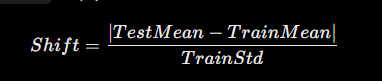

In [ ]:
drift_results = []

for test_session in sorted(model_data["session_id"].unique()):

    if test_session < 2:
        continue

    train_fold = (
        model_data[
            model_data["session_id"] < test_session
        ]
    )

    test_fold = (
        model_data[
            model_data["session_id"] == test_session
        ]
    )

    for feature in COMPACT_FEATURES:

        train_values = (
            train_fold[feature]
            .dropna()
        )

        test_values = (
            test_fold[feature]
            .dropna()
        )

        train_mean = train_values.mean()
        test_mean = test_values.mean()

        train_std = train_values.std(ddof=0)

        if (
            pd.isna(train_std)
            or np.isclose(train_std, 0)
        ):
            standardized_shift = np.nan
        else:
            standardized_shift = (
                abs(
                    test_mean
                    -
                    train_mean
                )
                /
                train_std
            )

        drift_results.append({
            "Test_Session":
                test_session,

            "Feature":
                feature,

            "Train_Mean":
                train_mean,

            "Test_Mean":
                test_mean,

            "Train_Std":
                train_std,

            "Standardized_Shift":
                standardized_shift
        })


feature_drift_df = (
    pd.DataFrame(
        drift_results
    )
)

feature_drift_df

In [ ]:
session_drift_summary = (
    feature_drift_df
    .groupby("Test_Session")
    .agg(
        Mean_Feature_Shift=(
            "Standardized_Shift",
            "mean"
        ),

        Median_Feature_Shift=(
            "Standardized_Shift",
            "median"
        ),

        Max_Feature_Shift=(
            "Standardized_Shift",
            "max"
        ),

        Features_Shift_GT_05=(
            "Standardized_Shift",
            lambda x: (
                x >= 0.5
            ).sum()
        ),

        Features_Shift_GT_10=(
            "Standardized_Shift",
            lambda x: (
                x >= 1.0
            ).sum()
        )
    )
    .reset_index()
)

session_drift_summary

In [ ]:
drift_pivot = (
    feature_drift_df
    .pivot(
        index="Feature",
        columns="Test_Session",
        values="Standardized_Shift"
    )
)

drift_pivot

In [ ]:
feature_drift_summary = (
    feature_drift_df
    .groupby("Feature")
    .agg(
        Mean_Shift=(
            "Standardized_Shift",
            "mean"
        ),
        Max_Shift=(
            "Standardized_Shift",
            "max"
        )
    )
    .sort_values(
        "Max_Shift",
        ascending=False
    )
)

feature_drift_summary

In [ ]:
failure_condition_table = (
    forward_v2[
        [
            "Test_Session",
            "Test_Defect_Rate",
            "PR_AUC",
            "ROC_AUC",
            "PR_Lift"
        ]
    ]
    .merge(
        session_drift_summary,
        on="Test_Session",
        how="left"
    )
)

failure_condition_table

## 15-6. Feature 영향 방향 안정성

Forward Validation 각 단계에서 Logistic Regression의 회귀계수를 비교한다.

동일 Feature가 생산시점에 따라 양수와 음수를 반복한다면,
해당 공정변수와 불량 사이의 관계가 시간적으로 안정적이지 않음을 의미한다.

이는 새로운 생산조건에서 모델 성능이 저하되는
Concept Drift의 근거로 활용할 수 있다.

In [ ]:
coefficient_results = []

for test_session in sorted(
    model_data["session_id"].unique()
):

    if test_session < 2:
        continue

    train_mask = (
        model_data["session_id"]
        < test_session
    )

    X_train = (
        model_data.loc[
            train_mask,
            COMPACT_FEATURES
        ]
        .copy()
    )

    y_train = (
        model_data.loc[
            train_mask,
            "Cycle_Defect"
        ]
        .astype(int)
    )

    model = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=5000,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    coef = (
        model
        .named_steps["model"]
        .coef_[0]
    )

    for feature, value in zip(
        COMPACT_FEATURES,
        coef
    ):

        coefficient_results.append({
            "Test_Session":
                test_session,

            "Feature":
                feature,

            "Coefficient":
                value,

            "Sign":
                np.sign(value)
        })


coefficient_df = pd.DataFrame(
    coefficient_results
)

In [ ]:
coefficient_pivot = (
    coefficient_df
    .pivot(
        index="Feature",
        columns="Test_Session",
        values="Coefficient"
    )
)

coefficient_pivot

In [ ]:
sign_pivot = (
    coefficient_df
    .pivot(
        index="Feature",
        columns="Test_Session",
        values="Sign"
    )
)

sign_pivot

In [ ]:
coef_stability = (
    coefficient_df
    .groupby("Feature")
    .agg(
        Mean_Coefficient=(
            "Coefficient",
            "mean"
        ),

        Std_Coefficient=(
            "Coefficient",
            "std"
        ),

        Positive_Folds=(
            "Coefficient",
            lambda x: (
                x > 0
            ).sum()
        ),

        Negative_Folds=(
            "Coefficient",
            lambda x: (
                x < 0
            ).sum()
        )
    )
)

coef_stability[
    "Sign_Consistency"
] = (
    coef_stability[
        [
            "Positive_Folds",
            "Negative_Folds"
        ]
    ]
    .max(axis=1)
    /
    (
        coef_stability[
            "Positive_Folds"
        ]
        +
        coef_stability[
            "Negative_Folds"
        ]
    )
)

coef_stability.sort_values(
    "Sign_Consistency"
)

| 실패 요인 | 판정 | 근거 |
|---|---|---|
| **Feature–Label granularity mismatch** | **확정** | 동일 Cycle RH/LH의 24개 센서값은 완전히 동일하지만 Label은 다름 |
| **Side 편향** | **확정** | 25개 불량이 전부 RH |
| **Covariate / Distribution Shift** | **확정** | `Clamp_Close_Time`, `Plasticizing_Time`의 미래 Session 분포 이동 |
| **Distribution Shift가 성능저하의 유일 원인** | **아님** | Shift가 가장 큰 Session 6에서 오히려 모델 성능이 가장 좋음 |
| **Feature–Defect 관계 불안정** | **강한 후보** | 7개 중 4개 Feature가 expanding fold에 따라 Logistic 계수 부호 변경 |
| **Label scarcity** | **확정** | 전체 불량 25개, 미래 Session별 불량 1~10개 |
| **안정적인 미래 우선검사 성능** | **확보 실패** | Forward ROC-AUC 0.484, PR-AUC 0.071 |

## 15-9. Failure Condition 중간 분석 결과

Forward Validation과 공정분포 변화를 함께 분석한 결과,
RG3 모델의 일반화 실패를 단순한 Distribution Shift 하나만으로 설명하기는 어려웠다.

### 1. Feature–Label Granularity 불일치

동일 생산 Cycle의 RH/LH는 24개 공정 센서값이 모두 동일하지만
25개의 불량 Cycle에서는 RH/LH 중 한쪽에만 불량 Label이 부여되어 있다.

따라서 현재 Cycle 단위 센서정보만으로
RH와 LH 중 어느 제품이 불량인지 완전하게 구분하는 것은 구조적으로 불가능하다.

### 2. Side Bias

Train의 제품 단위 불량 25건은 모두 RH에서 발생하였다.

Side를 예측변수로 사용할 경우 높은 성능이 나타날 수 있으나,
이는 공정 이상을 학습하는 것이 아니라 데이터셋의 Side 편향을 학습하는
Shortcut Learning이 될 가능성이 높아 핵심 모델에서는 제외하였다.

### 3. 공정분포 변화

미래 Session에서 일부 공정변수의 분포 이동이 확인되었다.

특히 다음 변수에서 큰 변화가 나타났다.

- Clamp_Close_Time
  - 평균 Standardized Shift: 약 1.36
  - 최대 Shift: 약 2.25

- Plasticizing_Time
  - 평균 Standardized Shift: 약 0.80
  - 최대 Shift: 약 1.14

따라서 과거 학습구간과 미래 생산구간 사이에 Covariate Shift가 존재한다.

그러나 가장 큰 Feature Shift를 보인 Session 6에서 오히려
가장 높은 Forward 성능이 관찰되었으므로,
Distribution Shift만으로 모델 실패를 설명할 수는 없다.

### 4. Feature–Defect 관계의 불안정 가능성

Expanding Window Logistic Regression의 계수를 비교한 결과
일부 Feature는 학습기간이 추가될 때 불량과의 관계 방향이 변경되었다.

반면 다음 두 Feature는 모든 Forward Fold에서 방향이 유지되었다.

- Barrel_Temperature_3_lag1: 지속적으로 음의 관계
- Barrel_Temperature_5_prev5_std: 지속적으로 양의 관계

따라서 모든 공정신호가 불안정한 것은 아니지만,
여러 주요 Feature에서 관계 방향이 변경되어
생산시점에 따른 Feature–Label 관계 변화 가능성이 존재한다.

이를 보다 직접적으로 확인하기 위해
과거 데이터에서 학습된 Feature 방향이 미래 Session에서도 유지되는지 추가 분석한다.

## 15-10. 과거 Feature–Defect 관계의 미래 재현성

Concept Drift 가능성을 보다 직접적으로 확인하기 위해
각 Forward Fold에서 과거 Train 데이터의 Feature–Defect 관계 방향과
미래 Test Session에서 실제로 나타난 관계 방향을 비교한다.

과거 Train에서 Feature 값이 높을수록 불량 가능성이 증가했다면,
미래 Session에서도 동일한 방향이 유지되는지 확인한다.

미래 Session에서 반대 방향이 반복적으로 나타날 경우
단순한 Feature 분포 이동뿐 아니라
Feature와 불량 사이 관계 자체가 시간에 따라 변화했을 가능성을 의미한다.

단, Session별 불량이 1~10건으로 매우 적으므로
본 분석은 Concept Drift의 확정적 통계 검정이 아니라
관계 안정성을 확인하기 위한 진단 분석으로 해석한다.

In [ ]:
relationship_shift_results = []

future_sessions = sorted(
    model_data["session_id"].unique()
)

for test_session in future_sessions:

    if test_session < 2:
        continue

    train_fold = (
        model_data[
            model_data["session_id"] < test_session
        ]
        .copy()
    )

    test_fold = (
        model_data[
            model_data["session_id"] == test_session
        ]
        .copy()
    )

    for feature in COMPACT_FEATURES:

        train_temp = (
            train_fold[
                [feature, "Cycle_Defect"]
            ]
            .dropna()
        )

        test_temp = (
            test_fold[
                [feature, "Cycle_Defect"]
            ]
            .dropna()
        )

        # Train/Test 모두 정상/불량 두 class 필요
        if (
            train_temp["Cycle_Defect"].nunique() < 2
            or
            test_temp["Cycle_Defect"].nunique() < 2
        ):
            continue

        # Feature가 상수면 분석 불가
        if (
            train_temp[feature].nunique() <= 1
            or
            test_temp[feature].nunique() <= 1
        ):
            continue

        # --------------------------------------
        # 과거 Train의 단변량 관계
        # --------------------------------------

        train_auc = roc_auc_score(
            train_temp["Cycle_Defect"],
            train_temp[feature]
        )

        train_direction = (
            "Higher"
            if train_auc >= 0.5
            else "Lower"
        )

        # --------------------------------------
        # 미래 Test Session의 실제 관계
        # --------------------------------------

        test_auc = roc_auc_score(
            test_temp["Cycle_Defect"],
            test_temp[feature]
        )

        # 과거 방향을 기준으로 orientation
        if train_auc >= 0.5:
            oriented_test_auc = test_auc
        else:
            oriented_test_auc = 1 - test_auc

        direction_match = (
            oriented_test_auc >= 0.5
        )

        relationship_shift_results.append({
            "Test_Session":
                test_session,

            "Feature":
                feature,

            "Train_Defects":
                int(
                    train_temp[
                        "Cycle_Defect"
                    ].sum()
                ),

            "Test_Defects":
                int(
                    test_temp[
                        "Cycle_Defect"
                    ].sum()
                ),

            "Train_AUC":
                train_auc,

            "Train_Direction":
                train_direction,

            "Test_AUC":
                test_auc,

            "Oriented_Test_AUC":
                oriented_test_auc,

            "Direction_Match":
                direction_match
        })


relationship_shift_df = pd.DataFrame(
    relationship_shift_results
)

relationship_shift_df

In [ ]:
session_relationship_summary = (
    relationship_shift_df
    .groupby("Test_Session")
    .agg(
        Features_Evaluated=(
            "Feature",
            "size"
        ),

        Direction_Matched=(
            "Direction_Match",
            "sum"
        ),

        Mean_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "mean"
        ),

        Median_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "median"
        )
    )
    .reset_index()
)

session_relationship_summary[
    "Direction_Match_Rate"
] = (
    session_relationship_summary[
        "Direction_Matched"
    ]
    /
    session_relationship_summary[
        "Features_Evaluated"
    ]
)

session_relationship_summary

In [ ]:
feature_relationship_stability = (
    relationship_shift_df
    .groupby("Feature")
    .agg(
        Future_Sessions=(
            "Test_Session",
            "nunique"
        ),

        Direction_Matched=(
            "Direction_Match",
            "sum"
        ),

        Mean_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "mean"
        ),

        Median_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "median"
        ),

        Min_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "min"
        ),

        Max_Oriented_Test_AUC=(
            "Oriented_Test_AUC",
            "max"
        )
    )
)

feature_relationship_stability[
    "Direction_Match_Rate"
] = (
    feature_relationship_stability[
        "Direction_Matched"
    ]
    /
    feature_relationship_stability[
        "Future_Sessions"
    ]
)

feature_relationship_stability = (
    feature_relationship_stability
    .sort_values(
        [
            "Direction_Match_Rate",
            "Median_Oriented_Test_AUC"
        ],
        ascending=False
    )
)

feature_relationship_stability

In [ ]:
relationship_auc_pivot = (
    relationship_shift_df
    .pivot(
        index="Feature",
        columns="Test_Session",
        values="Oriented_Test_AUC"
    )
)

relationship_auc_pivot

In [ ]:
relationship_direction_pivot = (
    relationship_shift_df
    .pivot(
        index="Feature",
        columns="Test_Session",
        values="Direction_Match"
    )
)

relationship_direction_pivot

In [ ]:
failure_relationship_table = (
    failure_condition_table
    .merge(
        session_relationship_summary[
            [
                "Test_Session",
                "Direction_Match_Rate",
                "Mean_Oriented_Test_AUC"
            ]
        ],
        on="Test_Session",
        how="left"
    )
)

failure_relationship_table

| 미래 Session | Mean Shift | Direction Match | PR Lift | ROC-AUC |
|---:|---:|---:|---:|---:|
| 2 | 0.219 | 66.7% | 2.79× | 0.658 |
| 3 | 0.415 | 66.7% | **0.89×** | 0.408 |
| 4 | 0.370 | 57.1% | 1.11× | 0.346 |
| 5 | 0.369 | 57.1% | 1.37× | 0.477 |
| **6** | **0.536** | **100%** | **4.70×** | **0.756** |

## 15-15. RG3 모델 Failure Condition 최종 분석

RG3 데이터에 대해 데이터 구조, 시간적 일반화, 공정분포 변화,
Feature–Defect 관계 안정성을 단계적으로 분석한 결과,
모델의 미래 일반화 실패는 하나의 원인이 아니라 여러 구조적 한계가 복합적으로 작용한 것으로 판단된다.

---

### 1. Feature–Label Granularity Mismatch — 확인됨

RG3 Train은 591개의 생산 Cycle에서 RH/LH 제품이 동시에 생성되는 구조이다.

동일 Cycle의 RH/LH는 24개 공정 센서값이 모두 동일하지만,
25개의 불량 Cycle에서는 RH/LH 중 한쪽만 불량 Label을 가진다.

즉,

> 공정 Feature는 Cycle 단위인데 품질 Label은 개별 Side 단위이다.

따라서 현재 센서만으로 RH와 LH 중 어느 제품이 불량인지
완전하게 구분하는 것은 구조적으로 불가능하다.

이에 따라 본 분석에서는 제품 단위 최종 판정보다
Cycle 단위 불량 위험 예측 문제로 재정의하였다.

---

### 2. Side Bias — 확인됨

제품 단위 25개 불량은 모두 RH에서 발생하였다.

따라서 Side를 Feature에 포함하면 높은 내부 성능을 만들 수 있지만,
이는 실제 공정 이상이 아니라 학습 데이터의 Side 편향을 이용하는
Shortcut Learning이 될 가능성이 높다.

이에 따라 핵심 예측모델에서는 Side를 제외하였다.

---

### 3. Label Scarcity — 확인됨

전체 Cycle 591개 중 불량은 25개로 약 4.23%에 불과하다.

또한 Forward Validation의 개별 미래 Session에는
불량이 1~10건밖에 존재하지 않는다.

따라서 복잡한 비선형 모델이나 다수의 파생변수를 사용하면
희소한 불량 패턴에 과적합될 위험이 매우 크다.

실제로 Compact Logistic Regression이
Random Forest, Extra Trees, HistGradientBoosting보다 높은
미래 일반화 성능을 보였다.

---

### 4. Covariate Shift — 확인됨

과거 Train 구간과 미래 생산 Session의 Feature 분포를 비교한 결과
일부 공정변수에서 상당한 이동이 확인되었다.

대표적으로:

- Clamp_Close_Time
  - 평균 Standardized Shift ≈ 1.36
  - 최대 Shift ≈ 2.25

- Plasticizing_Time
  - 평균 Standardized Shift ≈ 0.80
  - 최대 Shift ≈ 1.14

따라서 생산시점에 따라 공정조건의 분포가 변하고 있음이 확인되었다.

그러나 Distribution Shift가 가장 큰 Session 6에서
오히려 가장 높은 미래 예측성능이 나타났으므로,
분포 변화 자체가 모델 실패의 충분조건은 아니었다.

---

### 5. Feature–Defect 관계 불안정성 — 확인됨

과거 생산 데이터에서 확인된 Feature–Defect 관계가
미래 Session에서도 동일한 방향으로 유지되는지 분석하였다.

미래 Session별 관계 방향 일치율은 다음과 같이 나타났다.

- Session 2: 약 66.7%
- Session 3: 약 66.7%
- Session 4: 약 57.1%
- Session 5: 약 57.1%
- Session 6: 100%

특히 Session 6은 공정분포 이동이 가장 컸음에도
모든 평가 Feature의 관계 방향이 과거와 동일하게 유지되었으며,
Forward PR-AUC Lift 역시 약 4.70배로 가장 높았다.

반면 Session 3~5에서는 일부 Feature 관계가 반전되었으며
예측성능도 상대적으로 낮았다.

이는 모델 실패가 단순한 Covariate Shift보다는
생산구간에 따라 Feature와 불량 사이의 관계가 달라지는
Concept Drift 가능성과 관련되어 있음을 보여준다.

단, Session별 불량 표본이 매우 적으므로
Concept Drift의 통계적 확정이 아니라
**Feature–Label 관계 불안정성에 대한 진단 근거**로 해석한다.

---

## 종합 결론

RG3의 미래 불량 예측 성능이 제한되는 주요 원인은 다음 네 가지로 정리된다.

1. Cycle 단위 공정 Feature와 Side 단위 Label 사이의 정보 단위 불일치
2. RH에 집중된 Label 편향
3. 25건에 불과한 희소한 불량 Label
4. 생산 Session 변화에 따른 공정분포 및 Feature–Defect 관계의 불안정성

따라서 단순한 모델 복잡도 증가나 Hyperparameter Tuning만으로
RG3의 미래 일반화 문제를 해결하기 어렵다고 판단한다.

# 16. RG3 현장 활용방안

RG3 분석 결과 현재 제공된 데이터만으로
모든 미래 생산 Cycle에서 높은 불량 예측 성능을 보장하기는 어렵다.

따라서 모델을 최종 품질검사를 대체하는 자동 판정기로 사용하는 대신,
모델 신뢰도와 데이터 상태를 함께 판단하는 보조 의사결정 시스템으로 활용한다.

### 제안 운영 구조

#### 1. Cycle Risk Model

현재 Cycle의 공정변수와 최근 공정 변화량을 이용하여
불량 위험 Score를 계산한다.

단, 현재 분석에서 미래 일반화 성능이 충분하지 않았으므로
Risk Score만으로 제품의 Pass/Fail을 자동 결정하지 않는다.

#### 2. Process Shift Monitoring

현재 생산구간의 주요 공정변수 분포가
학습 당시 공정범위에서 얼마나 벗어났는지 지속적으로 감시한다.

특히 다음 변수의 변화 여부를 중점적으로 모니터링한다.

- Clamp_Close_Time
- Plasticizing_Time
- Barrel Temperature 계열

#### 3. Model Reliability Monitoring

최근 품질검사 결과가 축적되면
과거에 학습된 Feature–Defect 관계가 현재 생산구간에서도 유지되는지 확인한다.

관계 방향이 크게 변경되는 경우
기존 모델의 위험도를 그대로 신뢰하지 않고 재학습 후보로 판단한다.

#### 4. Abstention Policy

다음 조건에서는 모델이 자동 판단하지 않고 기존 검사공정을 유지한다.

- 새로운 생산조건이 학습범위를 크게 벗어나는 경우
- 최근 Feature–Defect 관계가 기존 학습관계와 크게 달라지는 경우
- 설비 재가동 또는 공정조건 변경 직후
- 충분한 최신 불량 Label이 확보되지 않은 경우

즉 RG3에서는

> "항상 예측하는 AI"보다  
> "예측 가능한 상황과 예측하면 안 되는 상황을 구분하는 AI"

를 제조현장 적용 방향으로 제안한다.

## 16-2. 추가 데이터 수집 및 공정 개선 제안

현재 RG3 데이터의 가장 큰 구조적 한계는
동일 Cycle의 RH/LH가 동일한 공정 센서값을 공유하면서
품질 Label은 개별 제품별로 다르게 부여된다는 점이다.

따라서 Side 단위 불량 원인을 식별하려면
Cycle 공통센서 외에 RH/LH를 구분할 수 있는 추가 정보가 필요하다.

### 추가 수집 우선순위

1. RH/LH별 금형 정보
   - Cavity별 금형온도
   - Cavity별 압력
   - 개별 충전 상태

2. 품질검사 실측값
   - 치수
   - 중량
   - 외관 불량 종류
   - 불량 발생 위치

3. 설비 상태 정보
   - 금형 교체
   - 설비 정비
   - 조건 변경 시점
   - 알람 발생 기록

4. 원재료 정보
   - Lot
   - 재료 건조조건
   - 투입시점

5. 충분한 시간축 Label
   - 여러 날짜 및 생산 Session의 불량 Label
   - 공정조건 변경 전후 Label
   - 새로운 생산환경의 Label

이를 통해 현재의 Cycle-level 위험예측에서
향후 Side/Cavity-level 불량 원인 분석으로 확장할 수 있다.

# 17. RG3 최종 결과 및 현장 활용방안

## 17-1. 최종 모델 선정

RG3 데이터에 대해 Original Feature, Temporal Feature, Compact Feature를 비교하고
Logistic Regression, Random Forest, Extra Trees, HistGradientBoosting 모델을 검증하였다.

최종적으로 가장 안정적인 성능을 보인 모델은 다음과 같다.

### 최종 모델

- Model: **Logistic Regression**
- Target: **Cycle_Defect**
  - 0: 해당 Cycle의 RH/LH 모두 정상
  - 1: 해당 Cycle에서 하나 이상의 불량 발생
- 데이터 단위: **Cycle 단위**
- 전체 Cycle: **591**
- 불량 Cycle: **25**
- 불량률: **4.23%**
- Feature 수: **7개**
- Class imbalance 처리: `class_weight="balanced"`

### 최종 사용 Feature

1. `Barrel_Temperature_5`
2. `Clamp_Close_Time`
3. `Plasticizing_Time`
4. `Barrel_Temperature_5_dev_prev5`
5. `Barrel_Temperature_5_prev5_std`
6. `Barrel_Temperature_3_lag1`
7. `Max_Back_Pressure_diff1`

다수의 Original 및 Temporal Feature를 모두 사용하는 것보다
소수의 Feature만 사용하는 Compact 모델이 더 높은 일반화 성능을 보였다.

## 17-2. 검증 방식별 최종 성능

모델 성능을 동일 데이터 분포 내부 평가뿐 아니라
새로운 생산 Session 및 실제 미래 생산 상황에 가까운 조건까지 단계적으로 검증하였다.

| 검증 방식 | PR-AUC | ROC-AUC | 해석 |
|---|---:|---:|---|
| Stratified Cross Validation | **0.1611** | **0.6546** | 동일 분포 내부 성능 |
| Leave-One-Session-Out | **0.0847** | **0.6116** | 보지 못한 생산 Session |
| Forward Validation | **0.0710** | **0.4841** | 과거 데이터로 미래 Session 예측 |

Forward Validation은 실제 제조현장 적용 상황과 가장 유사한 검증으로,
과거 생산 데이터만 이용해 이후 생산 Session을 예측하였다.

따라서 본 분석에서는 **Forward Validation 성능을 최종 일반화 성능으로 가장 중요하게 해석한다.**

### 최종 미래 예측 성능

- **PR-AUC: 0.0710**
- **ROC-AUC: 0.4841**
- Forward 평가 Cycle: **486개**
- Forward 평가 불량 Cycle: **21개**
- Forward 평가 불량률: **4.32%**

Random 모델의 기대 PR-AUC는 불량률과 동일한 약 **0.0432**이다.

따라서 PR-AUC는 Random 대비 약 **1.64배** 높은 수준으로
일부 불량 농축 신호는 확인되었다.

그러나 ROC-AUC는 0.5 이하이며,
미래 생산 전체에 대해 안정적으로 불량 위험 순위를 결정할 수 있는 수준의 성능은 확보하지 못하였다.

## 17-3. Recall / Precision 기반 검사 우선순위 평가

불량 예측 모델을 최종 Pass/Fail 판정기로 사용하는 대신,
위험도가 높은 Cycle을 먼저 검사하는 방식으로 활용 가능성을 평가하였다.

Forward Validation에서 생성된 Risk Score를 기준으로
위험도가 높은 Cycle부터 일정 비율을 검사했을 때의 성능은 다음과 같다.

| 검사 비율 | 검사 Cycle | 불량 포착 수 | Recall | Precision |
|---:|---:|---:|---:|---:|
| 상위 5% | 25 | 2 / 21 | **9.52%** | **8.00%** |
| 상위 10% | 49 | 3 / 21 | **14.29%** | **6.12%** |
| 상위 20% | 98 | 5 / 21 | **23.81%** | **5.10%** |
| 상위 30% | 146 | 6 / 21 | **28.57%** | **4.11%** |
| 상위 40% | 195 | 8 / 21 | **38.10%** | **4.10%** |
| 상위 50% | 243 | 12 / 21 | **57.14%** | **4.94%** |

### 지표 해석

Recall은 실제 불량 중 모델이 우선검사 대상으로 포착한 비율을 의미한다.

Precision은 모델이 우선검사 대상으로 지정한 Cycle 중 실제 불량이었던 비율이다.

예를 들어 위험도 상위 10%를 검사할 경우,

- 전체 486 Cycle 중 49 Cycle만 우선검사
- 실제 불량 21개 중 3개 포착
- Recall = **14.29%**
- Precision = **6.12%**

이다.

전체 불량률이 약 4.32%이므로 상위 5~10% 위험구간에는
불량이 Random보다 다소 농축되어 있으나,
높은 Recall을 확보하면서 검사량을 크게 줄이는 수준에는 도달하지 못하였다.

## 17-4. 최종 성능 판단

RG3 모델은 동일한 데이터 분포 내부에서는 일부 불량 분리 가능성을 보였다.

특히 Stratified Cross Validation에서는

- PR-AUC = **0.161**
- ROC-AUC = **0.655**

로 비교적 높은 성능이 나타났다.

그러나 검증조건을 실제 제조현장에 가깝게 변경할수록 성능이 감소하였다.

`Stratified → Leave-One-Session-Out → Forward`

순으로 PR-AUC가

**0.161 → 0.085 → 0.071**

로 감소하였다.

따라서 내부 Cross Validation 성능만을 이용해
RG3 모델의 실제 생산 성능을 평가할 경우 성능이 과대평가될 가능성이 있다.

최종적으로 현재 데이터만을 이용한 RG3 모델은

> **미래 불량을 높은 Recall과 Precision으로 안정적으로 자동 판정하는 모델**

수준에는 도달하지 못하였다.

## 17-5. 모델이 실패한 주요 원인

### 1. Feature와 Label의 데이터 단위 불일치

RG3 데이터는 하나의 생산 Cycle에서 RH/LH 제품이 동시에 생산된다.

동일 Cycle의 RH/LH는 24개의 공정 센서값이 모두 동일하지만,
불량 Cycle에서는 두 제품 중 한쪽만 불량으로 판정되는 사례가 존재한다.

즉,

> Feature는 Cycle 단위지만 Label은 제품 Side 단위이다.

따라서 현재 제공된 공정 센서만으로
RH와 LH 중 어느 제품이 불량인지 완전히 구분하는 것은 구조적으로 어렵다.

---

### 2. Side Bias

Train 데이터의 불량 제품 25건은 모두 RH에서 발생하였다.

따라서 `Side=RH`를 모델에 입력하면 높은 내부 성능이 나타날 수 있지만,
이는 공정 이상을 학습하는 것이 아니라 데이터셋의 Side 편향을 학습하는
Shortcut Learning이 될 가능성이 높다.

따라서 최종 모델에서는 Side를 사용하지 않았다.

---

### 3. 불량 데이터 부족

591개의 Cycle 중 불량 Cycle은 25개로 약 4.23%에 불과하다.

미래 Session별로는 불량이 1~10건밖에 존재하지 않아
복잡한 머신러닝 모델이 일반적인 불량 패턴보다
소수의 불량 사례를 암기할 위험이 높았다.

실제로 Random Forest, Extra Trees, HistGradientBoosting보다
단순한 Logistic Regression이 더 높은 미래 일반화 성능을 보였다.

---

### 4. 생산 Session에 따른 공정분포 변화

과거와 미래 생산구간 사이에서 일부 Feature의 분포가 크게 변경되었다.

특히

- `Clamp_Close_Time`
- `Plasticizing_Time`

에서 큰 Standardized Shift가 확인되었다.

따라서 생산시점에 따른 Covariate Shift가 존재한다.

---

### 5. Feature–Defect 관계의 불안정성

과거 생산 데이터에서 학습된 Feature와 불량 사이의 관계가
모든 미래 Session에서 동일하게 유지되지 않았다.

미래 Session별 Feature 관계 방향 일치율은 약

- 57%
- 67%
- 100%

등으로 생산구간에 따라 변하였다.

특히 가장 높은 Forward 성능을 보인 Session 6에서는
평가 가능한 Feature의 관계 방향이 **100% 유지**되었다.

반대로 일부 성능이 낮은 Session에서는
과거와 미래의 Feature–Defect 관계가 여러 변수에서 반전되었다.

따라서 단순한 공정분포 변화뿐 아니라
생산구간에 따른 Feature–Label 관계 불안정성이
미래 일반화 성능 저하의 주요 원인 중 하나로 판단된다.

## 17-6. 최종 현장 활용방안

현재 RG3 모델은 최종 품질검사를 대체하는 자동 Pass/Fail 판정기로 사용하기에는 성능이 부족하다.

따라서 다음과 같은 **보조 의사결정 시스템**으로 활용하는 것이 적절하다.

### 1. 불량 위험도 제공

각 생산 Cycle마다 불량 확률 또는 Risk Score를 계산하여
작업자에게 상대적인 위험도를 제공한다.

단, Risk Score만으로 제품을 불량으로 확정하지 않는다.

---

### 2. 검사 우선순위 보조

Risk Score가 높은 Cycle을 기존 품질검사보다 먼저 확인하도록 한다.

예를 들어 생산량이 매우 많아 모든 제품을 즉시 검사하기 어려운 경우,
위험도가 높은 Cycle을 먼저 검사하는 참고정보로 활용할 수 있다.

현재 모델의 미래 검증 결과에서는
상위 5~10% 위험구간에서 Random 대비 불량이 일부 농축되는 현상이 확인되었다.

그러나 Recall이 충분히 높지 않으므로
현재 단계에서는 기존 검사를 축소하거나 대체하지 않는다.

---

### 3. 모델 신뢰도 모니터링

현재 생산조건이 학습 당시 공정조건과 크게 달라진 경우
모델 예측값의 신뢰도를 낮게 평가한다.

특히 다음 공정변수를 지속적으로 모니터링할 필요가 있다.

- Clamp_Close_Time
- Plasticizing_Time
- Barrel Temperature 계열
- Back Pressure 계열

---

### 4. Abstention Policy 적용

다음 조건에서는 모델의 자동 판단을 중단하고
기존 상세검사를 그대로 수행한다.

- 새로운 생산조건이 학습범위를 크게 벗어난 경우
- 공정조건 변경 또는 설비 재가동 직후
- 최근 품질결과에서 기존 Feature–Defect 관계가 유지되지 않는 경우
- 새로운 생산 Session에 대한 Label이 충분히 확보되지 않은 경우

즉,

> **항상 판단하는 AI가 아니라, 판단 가능한 조건에서만 위험도를 제공하는 AI**

형태로 활용한다.

## 17-7. 향후 성능 개선을 위해 필요한 데이터

현재 RG3 데이터에서는 RH와 LH가 동일한 Cycle 센서를 공유하기 때문에
개별 제품 불량을 설명할 정보가 부족하다.

따라서 향후 다음 데이터를 추가로 수집할 필요가 있다.

### Side / Cavity 단위 데이터

- RH/LH별 금형온도
- Cavity별 압력
- Cavity별 충전 상태
- 개별 제품 위치 및 금형 정보

### 품질검사 데이터

- 제품 중량
- 치수 실측값
- 외관 불량 종류
- 불량 발생 위치
- 불량 심각도

### 설비 정보

- 설비 정비 시점
- 금형 교체 시점
- 공정조건 변경 이력
- 설비 Alarm
- 재가동 시점

### 원재료 정보

- 원재료 Lot
- 건조조건
- 투입시간
- 재료 교체 시점

### 추가 Label

현재 25건의 불량만으로는 미래 생산환경의 다양한 불량 패턴을 학습하기 어렵다.

따라서 여러 생산일과 여러 공정조건에서
추가적인 불량 Label을 지속적으로 확보하고,
새로운 생산환경의 데이터가 축적되면 주기적으로 모델을 재학습해야 한다.

# 18. RG3 최종 결론

RG3 데이터에서는 내부 Cross Validation 기준으로 일부 불량 예측 신호가 확인되었으나,
실제 미래 생산환경을 모사한 Forward Validation에서는 성능이 크게 감소하였다.

### 최종 성능

- 최종 모델: **Compact Logistic Regression**
- Feature: **7개**
- Forward PR-AUC: **0.071**
- Forward ROC-AUC: **0.484**
- Random PR-AUC 기준선: **약 0.043**
- 상위 5% 검사 Recall: **9.52%**
- 상위 5% 검사 Precision: **8.00%**
- 상위 10% 검사 Recall: **14.29%**
- 상위 10% 검사 Precision: **6.12%**
- 상위 20% 검사 Recall: **23.81%**
- 상위 20% 검사 Precision: **5.10%**

현재 모델은 Random보다 일부 높은 불량 농축 효과를 보였으나,
높은 Recall과 Precision을 동시에 확보하지 못해
최종 품질검사를 대체하거나 검사 대상을 대폭 축소할 수준에는 도달하지 못하였다.

그러나 분석을 통해 다음의 구체적인 실패조건을 확인하였다.

1. Cycle Feature와 Side Label 사이의 정보 단위 불일치
2. RH에 집중된 Label 편향
3. 25건에 불과한 희소 불량 데이터
4. 생산 Session에 따른 공정분포 변화
5. 생산구간별 Feature–Defect 관계 불안정성

따라서 RG3의 최종 활용방향은 단순 자동 불량판정보다

> **불량 위험도 제공 + 공정변화 감지 + 모델 신뢰도 판단 + 우선검사 보조**

로 설정한다.

특히 모델이 높은 확신을 갖는 상황과
예측을 신뢰해서는 안 되는 상황을 함께 판단하도록 설계함으로써
제조현장에서 보다 안전하게 활용할 수 있다.

본 결과는 현재 591 Cycle과 25개 불량 Label을 이용한 내부 분석 결과이며,
실제 신규 생산환경에 대한 최종 성능을 의미하지 않는다.
추가 생산기간 및 Side/Cavity 단위 데이터 확보 후 외부 검증이 필요하다.

# 19. 최종 RG3 모델 저장

모델 검증이 완료된 이후 실제 활용을 위해
전체 RG3 labeled Cycle 데이터를 이용하여 최종 모델을 다시 학습한다.

최종 모델은 다음과 같다.

- Model: Logistic Regression
- Target: Cycle_Defect
- Feature 수: 7개
- Missing Value 처리: Median Imputation
- Scaling: StandardScaler
- Class Imbalance: class_weight="balanced"

검증 과정에서는 Train/Validation을 분리하여 성능을 평가하였으나,
최종 배포용 모델은 검증 완료 후 확보된 전체 labeled 데이터를 이용하여 재학습한다.

단, 저장된 모델의 성능은 Forward Validation 결과인
PR-AUC 0.071을 기준으로 해석하며,
전체 데이터 재학습 모델 자체의 성능을 별도로 평가값으로 사용하지 않는다.

In [ ]:
FINAL_FEATURES = [
    "Barrel_Temperature_5",
    "Clamp_Close_Time",
    "Plasticizing_Time",
    "Barrel_Temperature_5_dev_prev5",
    "Barrel_Temperature_5_prev5_std",
    "Barrel_Temperature_3_lag1",
    "Max_Back_Pressure_diff1",
]

TARGET = "Cycle_Defect"

print("Final Feature 수:", len(FINAL_FEATURES))

for feature in FINAL_FEATURES:
    print("-", feature)

In [ ]:
X_final = (
    model_data[
        FINAL_FEATURES
    ]
    .copy()
)

y_final = (
    model_data[
        TARGET
    ]
    .astype(int)
    .copy()
)

print("=" * 70)
print("FINAL TRAIN DATA")
print("=" * 70)

print("X shape :", X_final.shape)
print("y shape :", y_final.shape)

print("\nTarget")
print(
    y_final.value_counts()
)

print("\nTarget Rate")
print(
    y_final.value_counts(
        normalize=True
    )
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


final_rg3_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),

    (
        "scaler",
        StandardScaler()
    ),

    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

final_rg3_model

In [ ]:
final_rg3_model.fit(
    X_final,
    y_final
)

print("Final RG3 Model Training Complete")

In [ ]:
import joblib
from pathlib import Path


MODEL_DIR = Path("./models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_PATH = (
    MODEL_DIR
    / "rg3_compact_logistic.joblib"
)


joblib.dump(
    final_rg3_model,
    MODEL_PATH
)


print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    "Path:",
    MODEL_PATH.resolve()
)

In [ ]:
FEATURE_PATH = (
    MODEL_DIR
    / "rg3_compact_features.joblib"
)

joblib.dump(
    FINAL_FEATURES,
    FEATURE_PATH
)

print(
    "Feature list saved:",
    FEATURE_PATH.resolve()
)

In [ ]:
import json
import sklearn
import pandas as pd
import numpy as np


model_metadata = {

    "model_name":
        "RG3 Compact Logistic Regression",

    "model_type":
        "LogisticRegression",

    "target":
        "Cycle_Defect",

    "target_definition": {
        "0":
            "RH/LH 모두 정상",

        "1":
            "해당 Cycle에서 하나 이상의 불량 발생"
    },

    "n_train_cycles":
        int(len(model_data)),

    "n_defect_cycles":
        int(
            model_data[
                "Cycle_Defect"
            ].sum()
        ),

    "defect_rate":
        float(
            model_data[
                "Cycle_Defect"
            ].mean()
        ),

    "features":
        FINAL_FEATURES,

    "n_features":
        len(FINAL_FEATURES),

    "preprocessing": {
        "missing":
            "Median Imputation",

        "scaling":
            "StandardScaler fitted on training data",

        "class_weight":
            "balanced"
    },

    "validation_result": {

        "stratified_pr_auc":
            0.161116,

        "stratified_roc_auc":
            0.654579,

        "loso_pr_auc":
            0.084686,

        "loso_roc_auc":
            0.611590,

        "forward_pr_auc":
            0.071039,

        "forward_roc_auc":
            0.484076
    },

    "forward_priority": {

        "top_5_percent": {
            "recall":
                0.095238,

            "precision":
                0.080000
        },

        "top_10_percent": {
            "recall":
                0.142857,

            "precision":
                0.061224
        },

        "top_20_percent": {
            "recall":
                0.238095,

            "precision":
                0.051020
        }
    },

    "limitations": [
        "Cycle-level sensor / Side-level label mismatch",
        "25 defect cycles only",
        "All labeled product-level defects occurred on RH",
        "Production session distribution shift",
        "Feature-defect relationship instability"
    ],

    "python_packages": {
        "pandas":
            pd.__version__,

        "numpy":
            np.__version__,

        "scikit_learn":
            sklearn.__version__
    }
}

In [ ]:
METADATA_PATH = (
    MODEL_DIR
    / "rg3_model_metadata.json"
)


with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_metadata,
        f,
        ensure_ascii=False,
        indent=4
    )


print(
    "Metadata saved:",
    METADATA_PATH.resolve()
)

In [ ]:
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_features = joblib.load(
    FEATURE_PATH
)


print(
    "Loaded Model:",
    loaded_model
)

print(
    "\nLoaded Features:",
    loaded_features
)

In [ ]:
prob_before = (
    final_rg3_model
    .predict_proba(
        X_final
    )[:, 1]
)

prob_after = (
    loaded_model
    .predict_proba(
        X_final[
            loaded_features
        ]
    )[:, 1]
)


same_prediction = np.allclose(
    prob_before,
    prob_after
)


print("=" * 70)
print("MODEL SAVE / LOAD CHECK")
print("=" * 70)

print(
    "Prediction 동일:",
    same_prediction
)

print(
    "Max difference:",
    np.max(
        np.abs(
            prob_before
            -
            prob_after
        )
    )
)

In [ ]:
model_data[
    "Final_RG3_Risk"
] = (
    loaded_model
    .predict_proba(
        model_data[
            loaded_features
        ]
    )[:, 1]
)


model_data[
    [
        "TimeStamp",
        "session_id",
        "Cycle_Defect",
        "Final_RG3_Risk"
    ]
].sort_values(
    "Final_RG3_Risk",
    ascending=False
).head(20)

In [ ]:
logistic_model = (
    final_rg3_model
    .named_steps["model"]
)


coefficient_df = pd.DataFrame({
    "Feature":
        FINAL_FEATURES,

    "Coefficient":
        logistic_model.coef_[0]
})


coefficient_df[
    "Abs_Coefficient"
] = (
    coefficient_df[
        "Coefficient"
    ].abs()
)


coefficient_df[
    "Direction"
] = np.where(
    coefficient_df[
        "Coefficient"
    ] > 0,

    "Risk Increase",

    "Risk Decrease"
)


coefficient_df = (
    coefficient_df
    .sort_values(
        "Abs_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficient_df

In [ ]:
COEF_PATH = (
    MODEL_DIR
    / "rg3_logistic_coefficients.csv"
)

coefficient_df.to_csv(
    COEF_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Coefficient saved:",
    COEF_PATH.resolve()
)

## 19-12. 최종 모델 저장 결과

최종 RG3 모델은 전체 591개 labeled Cycle을 이용하여 재학습한 후
다음 파일로 저장하였다.

### 저장 파일

- `rg3_compact_logistic.joblib`
  - Median Imputer
  - StandardScaler
  - Logistic Regression
  - 전체 전처리 및 모델 Pipeline

- `rg3_compact_features.joblib`
  - 최종 Feature 7개의 이름 및 순서

- `rg3_model_metadata.json`
  - 모델 구조
  - 학습 데이터 정보
  - 검증 성능
  - 모델 한계
  - 라이브러리 버전

- `rg3_logistic_coefficients.csv`
  - 최종 Logistic Regression Feature별 회귀계수

최종 모델을 전체 labeled 데이터로 재학습하였으나,
모델의 일반화 성능은 전체 데이터 재학습 결과가 아닌
**Forward Validation PR-AUC 0.071**을 기준으로 평가한다.

저장된 모델은 새로운 Cycle의 7개 Feature를 입력받아
불량 여부 자체가 아닌 **Cycle Defect Risk Score**를 출력하도록 활용한다.